<a href="https://colab.research.google.com/github/romesalarda/comp3226-password-manager-extension/blob/marianna/ecg-arrhythmia-v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Single-Lead ECG Arrhythmia Classification**



Arrhythmia Classification, 5 classes
======================================================

Based on: Md Rabiul Islam – Single Lead Arrhythmia Classification (2023)

Author: Marianna Kottas

Institution: University of Southampton

Programme: BSc Computer Science

Project: Enhancing Patient-Facing Interpretability in an ECG Arrhythmia Classifier

Model: CNN_LSTM with Attention


Dataset
-------
MIT-BIH Arrhythmia Database

• 48 ECG recordings from 47 patients  
• Sampling frequency: 360 Hz  
• Recording length: ~30 minutes per patient  


Task
----
Heartbeat classification into the 5 AAMI categories:

0 – Normal (N)  
1 – Supraventricular ectopic beat (S)  
2 – Ventricular ectopic beat (V)  
3 – Fusion beat (F)  
4 – Unknown / unclassifiable beat (Q)


Pipeline
--------
1. ECG signal loading
2. Wavelet denoising
3. R-peak extraction (using dataset annotations)
4. Heartbeat segmentation (300 samples per beat)
5. Class grouping (15 → 5 AAMI classes)
6. Training set balancing (undersampling + SMOTE)
7. CNN-LSTM classifier
8. Evaluation (accuracy, confusion matrix, per-class metrics)
9. Inference pipeline (prediction + confidence + clinical risk)


Model
-----
CNN-LSTM hybrid neural network implemented in TensorFlow / Keras.


Output
------
Prediction pipeline producing structured output:

```
{
  "prediction": class_name,
  "confidence": calibrated_probability,
  "risk_level": decision_risk_category,
  "conformal_set": candidate_class_names,
  "details": {
    "probabilities": class_probability_vector,
    "prediction_margin": margin_between_top_two_classes,
    "entropy": entropy_score,
    "entropy_normalised": normalised_entropy_score,
    "confidence_level": confidence_band_label,
    "class_index": predicted_class_index,
    "risk_score": decision_risk_score,
    "flags": decision_flags,
    "top_k": top_k_ranked_predictions,
    "prototype_indices": prototype_reference_indices
  },
  "explanations": {
    "importance_map": gradcam_importance_values,
    "prototype_labels": prototype_class_indices,
    "prototype_label_names": prototype_class_names,
    "prototype_similarities": prototype_similarity_scores
  },
  "clinical_risk": base_clinical_risk_category
}
```



Purpose
-------
The system is designed for integration into a patient-facing ECG
interpretation dashboard that communicates model predictions,
confidence, and clinical risk in an accessible format.

## **a. Summary**


*   **Task:** Arrhythmia Classification, 5 classes
*   **Dataset:** MIT-BIH ECG dataset, Dataset website: [Here](https://physionet.org/content/mitdb/1.0.0/)
*   **Model:** CNN_LSTM with Attention

## **b. Information about Dataset:**


The dataset can be downloaded from the original [website](https://physionet.org/content/mitdb/1.0.0/) or by clicking the [link](https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip) directly. The overall information about the dataset is given [here](https://archive.physionet.org/physiobank/database/html/mitdbdir/intro.htm).
1. The MIT-BIH dataset contains **48 readings**.
2. Number of **patients = 47** (25 Men, 22 Women). Only 1 patient has 2 readings. Rest 1 readings/patients.
3. Each reading contains a. ECG signals b. Annotations
4. ECG signals length = **30 Minutes** (or slightly over). Sampling Frequency = **360 Hz**.
5. Each reading contains **2 Lead ECG** signals that are Modified Limb Lead II and Modified Lead V1 (Occationally V2, V5, V4 just only once). Simply, Two Leads: **MLII, V1**.
6. Annotation is provided for each beat. The MIT-BIH database contains a wider set of annotated beat symbols, but this study retains the canonical 15-symbol subset commonly used for AAMI-style grouping into 5 superclasses: N, S, V, F, and Q.
* N - Normal
* S - Supraventricular premature beat
* V - Premature ventricular contraction
* F - Fusion of ventricular and normal beat
* Q - Unclassifiable / Unknown beat

# **Main Parts of the Study:**

#### **A — Setup & Environment**
#### **B — Signal Processing Pipeline**
#### **C — Dataset Construction**
#### **D — Dataset Splitting & Balancing**
#### **E — Model Architecture & Training**
#### **F — Calibration (Temperature Scaling + ECE)**
#### **G — Uncertainty Modelling (Conformal Prediction)**
#### **H — Evaluation & Performance Analysis**
#### **I — Explainability (Grad-CAM)**
#### **J — Prototype-Based Explanation**
#### **K — Robustness Testing (Noise Stress)**
#### **L — Decision Layer (Accept / Defer)**
#### **M — External Validation (INCART)**
#### **N — Inference System (Deployment Pipeline)**
#### **O — Natural Language Generation (NLG)**
#### **P — Demonstration & Visualisation**
#### **Q — Sanity Checks & Verification**

# **A — Setup & Environment**

## **A0 — Drive & Paths**

In [1]:
# ==========================================================
# A0 — Drive & Paths
# ==========================================================

from google.colab import drive
import os

drive.mount('/content/drive')

MODEL_DIR = "/content/drive/MyDrive/ecg_model"
MODEL_NAME = "ecg_model_patientwise_balanced_attention_v2.keras"
WEIGHTS_NAME = "best_weights_patientwise_balanced_attention_v2.weights.h5"

MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)
CHECKPOINT_PATH = os.path.join(MODEL_DIR, WEIGHTS_NAME)

RESULTS_DIR = os.path.join(MODEL_DIR, "results")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TAB_DIR = os.path.join(RESULTS_DIR, "tables")
METRIC_DIR = os.path.join(RESULTS_DIR, "metrics")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)

print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))
print("Model directory:", MODEL_DIR)
print("Model path:", MODEL_PATH)
print("Checkpoint path:", CHECKPOINT_PATH)
print("Model exists:", os.path.exists(MODEL_PATH))
print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH))

Mounted at /content/drive
Drive mounted: True
Model directory: /content/drive/MyDrive/ecg_model
Model path: /content/drive/MyDrive/ecg_model/ecg_model_patientwise_balanced_attention_v2.keras
Checkpoint path: /content/drive/MyDrive/ecg_model/best_weights_patientwise_balanced_attention_v2.weights.h5
Model exists: False
Checkpoint exists: False


## **A1 — Package Installation**

In [2]:
# ==========================================================
# A1 — Package Installation
# ==========================================================

!pip install -q wfdb neurokit2 plotly imbalanced-learn PyWavelets pydot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 50.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


## **A2 — Reproducibility + Utilities**

In [3]:
# ==========================================================
# A2 — Reproducibility + Utilities
# ==========================================================

import os
import json
import random
import datetime
from collections import Counter
from os.path import join as osj

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt
import wfdb
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    multilabel_confusion_matrix
)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Reproducibility seed set to", SEED)

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------
BASE = "/content/data"
MIT = os.path.join(BASE, "mitdb")
os.makedirs(MIT, exist_ok=True)

if not os.path.exists(os.path.join(MIT, "RECORDS")):
    wfdb.dl_database("mitdb", dl_dir=MIT)
    print("MIT-BIH dataset downloaded.")
else:
    print("MIT-BIH dataset already present.")

project_path = MIT
DATA_ROOT = MIT
RECORDS = os.path.join(MIT, "RECORDS")

MODEL_DIR = "/content/drive/MyDrive/ecg_model"
RESULTS_DIR = os.path.join(MODEL_DIR, "results")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TAB_DIR = os.path.join(RESULTS_DIR, "tables")
METRIC_DIR = os.path.join(RESULTS_DIR, "metrics")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)

print("MIT path:", MIT)
print("Results dir:", RESULTS_DIR)
print("Pandas version:", pd.__version__)
print("WFDB version:", wfdb.__version__)

# ----------------------------------------------------------
# Constants
# ----------------------------------------------------------
CLASS_NAMES_SHORT = ["N", "S", "V", "F", "Q"]
CLASS_NAMES_FULL = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]

PRE_R = 99
POST_R = 201
SEG_LEN = PRE_R + POST_R  # 300

# ----------------------------------------------------------
# Patient grouping for strict patient-wise splitting
# MIT-BIH has 48 records from 47 patients.
# Records 201 and 202 belong to the same subject and must
# never be split across train / validation / test.
# ----------------------------------------------------------
PATIENT_GROUP_MAP = {
    "100": "100",
    "101": "101",
    "102": "102",
    "103": "103",
    "104": "104",
    "105": "105",
    "106": "106",
    "107": "107",
    "108": "108",
    "109": "109",
    "111": "111",
    "112": "112",
    "113": "113",
    "114": "114",
    "115": "115",
    "116": "116",
    "117": "117",
    "118": "118",
    "119": "119",
    "121": "121",
    "122": "122",
    "123": "123",
    "124": "124",
    "200": "200",
    "201": "201_202",
    "202": "201_202",
    "203": "203",
    "205": "205",
    "207": "207",
    "208": "208",
    "209": "209",
    "210": "210",
    "212": "212",
    "213": "213",
    "214": "214",
    "215": "215",
    "217": "217",
    "219": "219",
    "220": "220",
    "221": "221",
    "222": "222",
    "223": "223",
    "228": "228",
    "230": "230",
    "231": "231",
    "232": "232",
    "233": "233",
    "234": "234",
}

def record_to_patient_group(record_id):
    record_id = str(record_id)
    if record_id not in PATIENT_GROUP_MAP:
        raise KeyError(f"Record {record_id} missing from PATIENT_GROUP_MAP")
    return PATIENT_GROUP_MAP[record_id]

# ----------------------------------------------------------
# Utility helpers
# ----------------------------------------------------------
def flatten_labels(y):
    return np.asarray(y, dtype=np.int64).reshape(-1)

def savefig_drive(fig, filename, dpi=300, close=True):
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")
    if close:
        plt.close(fig)

def compute_ece(probs, labels, n_bins=15):
    labels = flatten_labels(labels)
    probs = np.asarray(probs, dtype=np.float64)

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correct = (predictions == labels).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidences >= bin_edges[i]) & (confidences <= bin_edges[i + 1])
        else:
            mask = (confidences >= bin_edges[i]) & (confidences < bin_edges[i + 1])

        if np.any(mask):
            acc_bin = np.mean(correct[mask])
            conf_bin = np.mean(confidences[mask])
            ece += np.abs(acc_bin - conf_bin) * (np.sum(mask) / len(labels))

    return float(ece)

def reliability_curve_points(probs, labels, n_bins=10):
    labels = flatten_labels(labels)
    probs = np.asarray(probs, dtype=np.float64)

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correct = (predictions == labels).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    mean_conf, mean_acc = [], []

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidences >= bin_edges[i]) & (confidences <= bin_edges[i + 1])
        else:
            mask = (confidences >= bin_edges[i]) & (confidences < bin_edges[i + 1])

        if np.any(mask):
            mean_conf.append(np.mean(confidences[mask]))
            mean_acc.append(np.mean(correct[mask]))

    return np.array(mean_conf), np.array(mean_acc)

def macro_brier_score(y_true, probs, num_classes=5):
    y_true = flatten_labels(y_true)
    y_onehot = np.eye(num_classes)[y_true]
    return float(np.mean([
        brier_score_loss(y_onehot[:, c], probs[:, c])
        for c in range(num_classes)
    ]))

def per_class_metrics_dataframe(y_true, y_pred, class_names=CLASS_NAMES_SHORT):
    y_true = flatten_labels(y_true)
    y_pred = flatten_labels(y_pred)

    mcm = multilabel_confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names))
    )

    rows = []
    for i, class_name in enumerate(class_names):
        tn, fp, fn, tp = mcm[i].ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
        acc = (tp + tn) / (tp + tn + fp + fn)

        rows.append({
            "Class": class_name,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Precision": precision,
            "F1": f1,
            "PerClassAccuracy": acc,
            "TP": int(tp),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn)
        })

    return pd.DataFrame(rows)

def confidence_band(conf):
    if conf >= 0.80:
        return "High"
    elif conf >= 0.60:
        return "Medium"
    return "Low"

Reproducibility seed set to 42
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generatin

# **B — Signal Processing Pipeline**

## **B1 — Wavelet Denoising**
Noise removing by using Discrete Wavelet Transform (DWT)

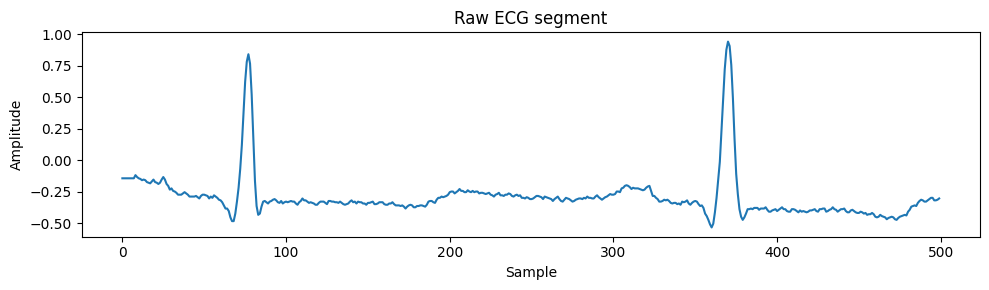

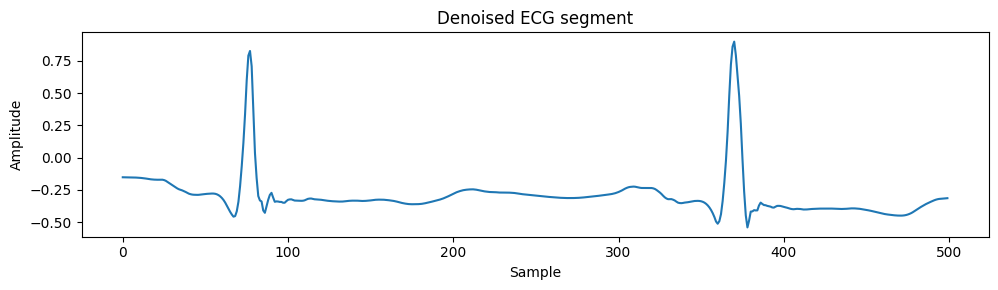

In [4]:
# ==========================================================
# B1 — Denoising
# ==========================================================

def denoise(data):
    """
    Wavelet-based ECG denoising using db5 decomposition.
    Returns a reconstructed denoised 1D signal.
    """
    coeffs = pywt.wavedec(data=data, wavelet="db5", level=9)
    cA9, cD9, cD8, cD7, cD6, cD5, cD4, cD3, cD2, cD1 = coeffs

    threshold = (np.median(np.abs(cD1)) / 0.6745) * np.sqrt(2 * np.log(len(cD1)))

    cD1.fill(0)
    cD2.fill(0)

    for i in range(1, len(coeffs) - 2):
        coeffs[i] = pywt.threshold(coeffs[i], threshold)

    rdata = pywt.waverec(coeffs=coeffs, wavelet="db5")
    return rdata


# ----------------------------------------------------------
# Example visualisation
# ----------------------------------------------------------
record_path_100 = os.path.join(project_path, "100")
record = wfdb.rdrecord(record_path_100, channel_names=["MLII"])
data = record.p_signal.flatten()

plt.figure(figsize=(10, 3))
plt.plot(data[0:500])
plt.title("Raw ECG segment")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

rdata = denoise(data=data)

plt.figure(figsize=(10, 3))
plt.plot(rdata[0:500])
plt.title("Denoised ECG segment")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## **B2 — R-Peak Extraction (Annotations)**
R-peak is annotated in MIT-BIH dataset. Just need to read the file.

[    18     77    370 ... 649484 649734 649991]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', '

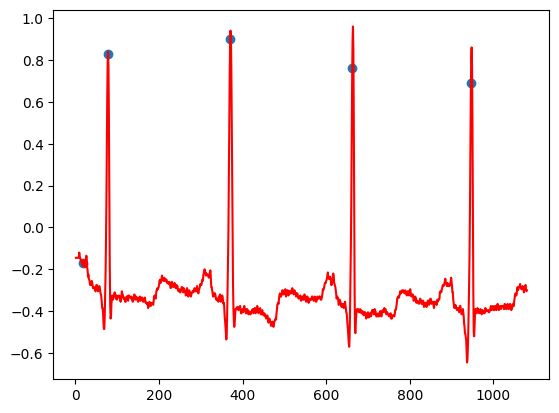

In [5]:
# For exmaple, we extract '100' recording annotation
annotation = wfdb.rdann(record_path_100, "atr")
Rlocation = annotation.sample
print(Rlocation)
Rclass = annotation.symbol
print(Rclass)

len(annotation.symbol)

# R-peak ploting
x = np.arange(1, 1081)

n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])

plt.plot(x, data[0:1080], color='red')
plt.scatter(r_peak_x, r_peak_y)

## **B3 — Heartbeat Segmentation**
Each ECG signal is segmented by using a window **length of 300**. From R-peak location, **99** samples taken from **left** and **201** samples from **right**. Thus a complete **heartbeat** is found.

(300,)
(300,)
(300,)


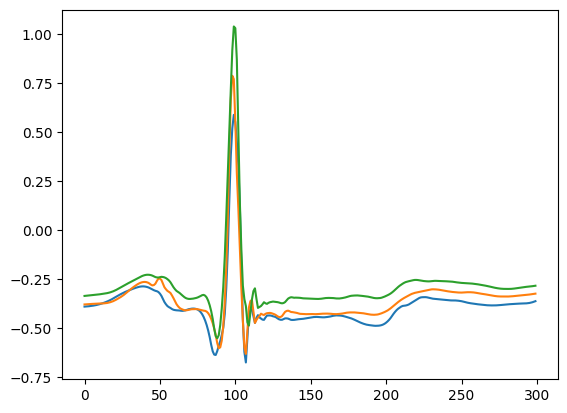

In [6]:
# Plotting 3 heartbeats
k = np.arange(100, 103)
for i in k:
  # print(i)
  # print(Rlocation[i] - 99, Rlocation[i] + 201)
  x_train = rdata[Rlocation[i] - 99:Rlocation[i] + 201]
  plt.plot(x_train)
  print(x_train.shape)
plt.show()

## **B4 — Preprocessing Visualisation**

In [7]:
# ==========================================================
# B4 — Complete preprocessing figure
# ==========================================================

r_peak_xx = [Rlocation[0], Rlocation[1], Rlocation[2], Rlocation[3]]
r_peak_yy = [rdata[Rlocation[0]], rdata[Rlocation[1]], rdata[Rlocation[2]], rdata[Rlocation[3]]]

fig = plt.figure(figsize=(10, 9), dpi=600)
x = np.arange(1, 1081)

# Raw signal
plt.subplot(3, 1, 1)
plt.plot(x / 360, data[0:1080], color="red")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")
plt.title("Raw ECG signal")

# Denoised signal
plt.subplot(3, 1, 2)
plt.plot(x / 360, rdata[0:1080], color="red")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")
plt.title("Denoised ECG signal")

# Segmentation visualisation
plt.subplot(3, 1, 3)
n_peak = 5
r_peak_x = [Rlocation[i] for i in range(n_peak)]
r_peak_y = [rdata[Rlocation[i]] for i in range(n_peak)]

plt.plot(x, rdata[0:1080], color="red")
plt.scatter(r_peak_x, r_peak_y)

plt.axvline(x=Rlocation[2], color="k", linestyle=":")
plt.axvline(x=Rlocation[2] - PRE_R, color="k", linestyle="--")
plt.axvline(x=Rlocation[2] + POST_R, color="k", linestyle="--")

plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.title("Segmentation using 3rd R-peak")

plt.subplots_adjust(
    left=0.1,
    bottom=0.1,
    right=0.9,
    top=0.9,
    wspace=0.4,
    hspace=0.4
)

savefig_drive(fig, "Denoised_and_segmented_ECG.png")
plt.show()

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/Denoised_and_segmented_ECG.png


# **C — Dataset Construction**

## **C1 — MIT-BIH Record Loading**

<class 'numpy.ndarray'>
(650000,)
{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal']}
Signal of patient 100 extracted
Signal of patient 101 extracted
Signal of patient 102 extracted
Signal of patient 103 extracted
Signal of patient 104 extracted
Signal of patient 105 extracted
Signal of patient 106 extracted
Signal of patient 107 extracted
Signal of patient 108 extracted
Signal of patient 109 extracted
Signal of patient 111 extracted
Signal of patient 112 extracted
Signal of patient 113 extracted
Signal of patient 114 extracted
Signal of patient 115 extracted
Signal of patient 116 extracted
Signal of patient 117 extracted
Signal of patient 118 extracted
Signal of patient 119 extracted
Signal of patient 121 extracted
Signal of patient 122 extracted
Signal of patient 123 extracted
Signal of patient 124 extracted
Signal of patient 200 extracted
Signal of p

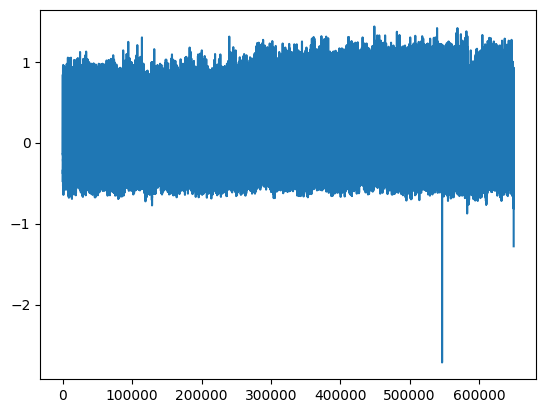

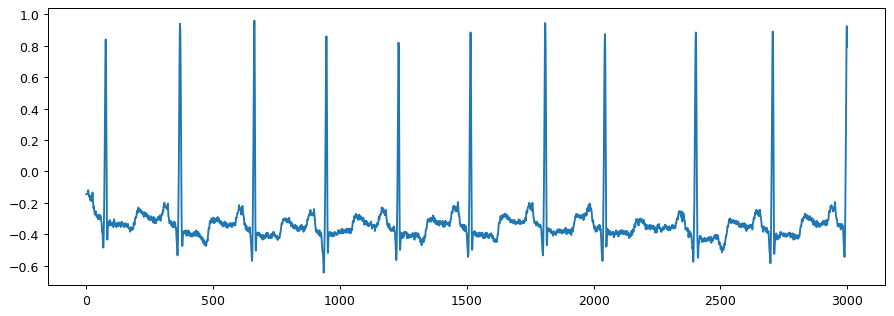

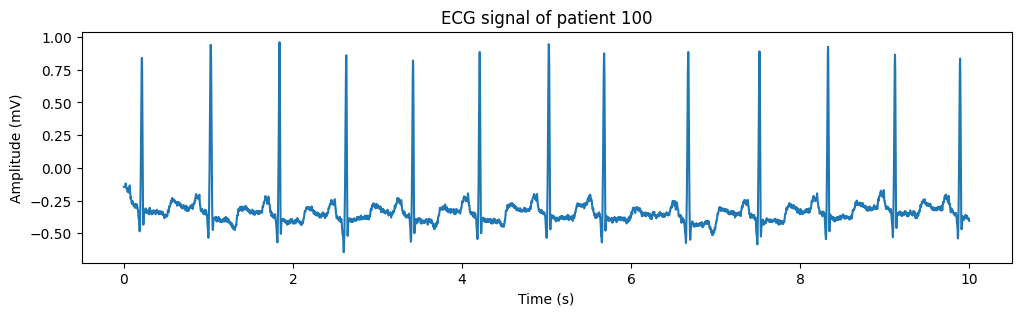

{'fs': 360,
 'sig_len': 650000,
 'n_sig': 2,
 'base_date': None,
 'base_time': None,
 'units': ['mV', 'mV'],
 'sig_name': ['MLII', 'V5'],
 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal'],
 'resolution': 2048}

In [8]:
import wfdb

patient_ids = wfdb.get_record_list("mitdb")
patient_ids

#Extracting just 1 patient ECG signal and info
lead0 = {}  # without this it shows lead0[100] is not defined
lead1 = {}
patient_id = 100
signals, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(100)))
lead0[100] = signals[:, 0]
lead1[100] = signals[:, 1]

# Visualization of 1 patients signal and info
print(type(lead0[100]))
print(lead0[100].shape)
plt.plot(lead0[100])
print(info)

# ECG signal per second
a = lead0[100][0: 3000]
plt.figure(figsize=(12, 4), dpi=90)
plt.plot(a)

# Load all patient ECG signals and info

def get_ecg_signals(patient_ids, data_root=DATA_ROOT):
    lead0 = {}
    lead1 = {}

    for pid in patient_ids:
        signals, info = wfdb.io.rdsamp(osj(data_root, str(pid)))
        lead0[str(pid)] = signals[:, 0]
        lead1[str(pid)] = signals[:, 1]
        print(f"Signal of patient {pid} extracted")

    return lead0, lead1


def get_ecg_info(patient_id, data_root=DATA_ROOT):
    _, info = wfdb.io.rdsamp(osj(data_root, str(patient_id)))
    info["resolution"] = 2**11
    return info


lead0, lead1 = get_ecg_signals(patient_ids)

# Plot any patient signal from any time frame
patient_id = "100"
starting_time = 0
ending_time = 10
fs = 360

starting_signal_point = starting_time * fs
ending_signal_point = ending_time * fs

x = np.arange(starting_time, ending_time, 1 / fs)
signal = lead0[patient_id][starting_signal_point:ending_signal_point]

plt.figure(figsize=(12, 3), dpi=100)
plt.plot(x, signal)
plt.title(f"ECG signal of patient {patient_id}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.show()

ecg_info = get_ecg_info(patient_ids[0])
ecg_info

## **C2 — Beat Class Mapping (15-Class to 5-Class AAMI)**

In [9]:
# ==========================================================
# C2 — Beat Class Mapping (15-Class to 5-Class AAMI)
# ==========================================================

# Canonical 15 MIT-BIH beat symbols retained for diagnostics / 15-class plots
ECG_CLASS_SET_15 = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q']

# Canonical 15-class index mapping
SYMBOL_TO_LABEL15 = {
    'N': 0,
    'L': 1,
    'R': 2,
    'e': 3,
    'j': 4,
    'A': 5,
    'a': 6,
    'J': 7,
    'S': 8,
    'V': 9,
    'E': 10,
    'F': 11,
    '/': 12,
    'f': 13,
    'Q': 14
}

# Symbol -> AAMI 5-class label
# N = 0, S = 1, V = 2, F = 3, Q = 4
AAMI_SYMBOL_TO_LABEL5 = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3,
    '/': 4, 'f': 4, 'Q': 4
}

CLASS_NAMES_SHORT = ["N", "S", "V", "F", "Q"]
CLASS_NAMES_FULL = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]

def map_to_label15(symbol):
    """
    Map MIT-BIH annotation symbol to canonical 15-class index.
    Returns None for symbols excluded from the study.
    """
    return SYMBOL_TO_LABEL15.get(symbol, None)

def map_to_aami(symbol):
    """
    Map MIT-BIH annotation symbol to 5-class AAMI index.
    Returns None for symbols excluded from the study.
    """
    return AAMI_SYMBOL_TO_LABEL5.get(symbol, None)

def is_valid_aami_symbol(symbol):
    """
    True only for symbols explicitly retained in the 15-beat study set.
    """
    return symbol in SYMBOL_TO_LABEL15 and symbol in AAMI_SYMBOL_TO_LABEL5

## **C3 — Dataset Construction**

In [10]:
# ==========================================================
# C3 — Dataset Construction
# Strict dataset construction with record IDs + patient-group IDs
# ==========================================================

NUMBER_SET = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

def choose_single_lead(record_id):
    record = wfdb.rdrecord(os.path.join(project_path, record_id))
    sig_names = list(record.sig_name)

    if "MLII" in sig_names:
        lead_name = "MLII"
    else:
        lead_name = sig_names[0]

    return lead_name

def get_dataset_for_record(
    record_id,
    X_data,
    Y15_data,
    Y5_data,
    record_ids,
    patient_group_ids
):
    lead_name = choose_single_lead(record_id)
    patient_group = record_to_patient_group(record_id)

    print(f"{record_id}: using channel {lead_name} | patient_group={patient_group}")

    record = wfdb.rdrecord(
        os.path.join(project_path, record_id),
        channel_names=[lead_name]
    )
    data = record.p_signal.flatten()
    rdata = denoise(data)

    annotation = wfdb.rdann(os.path.join(project_path, record_id), "atr")
    r_locations = annotation.sample
    r_classes = annotation.symbol

    for i in range(len(r_classes)):
        beat_symbol = r_classes[i]

        # Keep only the canonical 15-symbol set used in the study
        if not is_valid_aami_symbol(beat_symbol):
            continue

        label_15 = map_to_label15(beat_symbol)
        label_5 = map_to_aami(beat_symbol)

        if label_15 is None or label_5 is None:
            continue

        left = r_locations[i] - PRE_R
        right = r_locations[i] + POST_R

        if left < 0 or right > len(rdata):
            continue

        segment = rdata[left:right]

        if len(segment) != SEG_LEN:
            continue

        segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

        X_data.append(segment.astype(np.float32))
        Y15_data.append(int(label_15))
        Y5_data.append(int(label_5))
        record_ids.append(str(record_id))
        patient_group_ids.append(str(patient_group))

    return X_data, Y15_data, Y5_data, record_ids, patient_group_ids

def load_data():
    data_set = []
    label15_set = []
    label5_set = []
    record_set = []
    patient_group_set = []

    for record_id in NUMBER_SET:
        print(f"Loading record {record_id} ...")
        data_set, label15_set, label5_set, record_set, patient_group_set = get_dataset_for_record(
            record_id,
            data_set,
            label15_set,
            label5_set,
            record_set,
            patient_group_set
        )

    X = np.asarray(data_set, dtype=np.float32).reshape(-1, SEG_LEN)
    Y15 = np.asarray(label15_set, dtype=np.int64).reshape(-1)
    Y5 = np.asarray(label5_set, dtype=np.int64).reshape(-1)
    record_ids = np.asarray(record_set, dtype=str)
    patient_group_ids = np.asarray(patient_group_set, dtype=str)

    print("X shape:", X.shape)
    print("Y15 shape:", Y15.shape)
    print("Y5 shape:", Y5.shape)
    print("record_ids shape:", record_ids.shape)
    print("patient_group_ids shape:", patient_group_ids.shape)
    print("Unique patient groups:", len(np.unique(patient_group_ids)))

    return X, Y15, Y5, record_ids, patient_group_ids

# ----------------------------------------------------------
# Load canonical dataset
# ----------------------------------------------------------
X_all, Y15_all, Y5_all, record_ids_all, patient_group_ids_all = load_data()

X_all = np.asarray(X_all, dtype=np.float32)
Y15_all = np.asarray(Y15_all, dtype=np.int64)
Y5_all = np.asarray(Y5_all, dtype=np.int64)
record_ids_all = np.asarray(record_ids_all, dtype=str)
patient_group_ids_all = np.asarray(patient_group_ids_all, dtype=str)

Loading record 100 ...
100: using channel MLII | patient_group=100
Loading record 101 ...
101: using channel MLII | patient_group=101
Loading record 102 ...
102: using channel V5 | patient_group=102
Loading record 103 ...
103: using channel MLII | patient_group=103
Loading record 104 ...
104: using channel V5 | patient_group=104
Loading record 105 ...
105: using channel MLII | patient_group=105
Loading record 106 ...
106: using channel MLII | patient_group=106
Loading record 107 ...
107: using channel MLII | patient_group=107
Loading record 108 ...
108: using channel MLII | patient_group=108
Loading record 109 ...
109: using channel MLII | patient_group=109
Loading record 111 ...
111: using channel MLII | patient_group=111
Loading record 112 ...
112: using channel MLII | patient_group=112
Loading record 113 ...
113: using channel MLII | patient_group=113
Loading record 114 ...
114: using channel MLII | patient_group=114
Loading record 115 ...
115: using channel MLII | patient_group=115

## **C4 — Dataset Diagnostics and Class Distribution**

In [11]:
# ----------------------------------------------------------
# C4 — Dataset Diagnostics and Class Distribution
# ----------------------------------------------------------

# ----------------------------------------------------------
# Create clean tabular metadata views without mixed-type hstack
# ----------------------------------------------------------
feature_cols = [f"x_{i}" for i in range(SEG_LEN)]

df_beats_5 = pd.DataFrame(X_all, columns=feature_cols)
df_beats_5["label_5"] = Y5_all.astype(np.int64)
df_beats_5["record_id"] = record_ids_all.astype(str)
df_beats_5["patient_group_id"] = patient_group_ids_all.astype(str)

df_beats_15 = pd.DataFrame(X_all, columns=feature_cols)
df_beats_15["label_15"] = Y15_all.astype(np.int64)
df_beats_15["record_id"] = record_ids_all.astype(str)
df_beats_15["patient_group_id"] = patient_group_ids_all.astype(str)

print("df_beats_5 shape:", df_beats_5.shape)
print("df_beats_15 shape:", df_beats_15.shape)
print("Unique records:", len(np.unique(record_ids_all)))
print("Unique patient groups:", len(np.unique(patient_group_ids_all)))

print("15-class distribution:", Counter(Y15_all))
print("5-class distribution:", Counter(Y5_all))

# ----------------------------------------------------------
# Save dataset diagnostics
# ----------------------------------------------------------
dataset_counts_15 = pd.DataFrame(
    Counter(Y15_all).items(),
    columns=["Class15", "Count"]
).sort_values("Class15")

dataset_counts_5 = pd.DataFrame(
    Counter(Y5_all).items(),
    columns=["Class5", "Count"]
).sort_values("Class5")

dataset_counts_15.to_csv(os.path.join(METRIC_DIR, "dataset_counts_15.csv"), index=False)
dataset_counts_5.to_csv(os.path.join(METRIC_DIR, "dataset_counts_5.csv"), index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dataset_counts_5["Class5"].astype(str), dataset_counts_5["Count"])
ax.set_xlabel("5-class label")
ax.set_ylabel("Count")
ax.set_title("Full 5-Class Dataset Distribution")
plt.tight_layout()
savefig_drive(fig, "full_5class_distribution.png")

df_beats_5 shape: (109446, 303)
df_beats_15 shape: (109446, 303)
Unique records: 48
Unique patient groups: 47
15-class distribution: Counter({np.int64(0): 75017, np.int64(1): 8072, np.int64(2): 7255, np.int64(9): 7129, np.int64(12): 7024, np.int64(5): 2546, np.int64(13): 982, np.int64(11): 802, np.int64(4): 229, np.int64(6): 150, np.int64(10): 106, np.int64(7): 83, np.int64(14): 33, np.int64(3): 16, np.int64(8): 2})
5-class distribution: Counter({np.int64(0): 90589, np.int64(4): 8039, np.int64(2): 7235, np.int64(1): 2781, np.int64(3): 802})
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/full_5class_distribution.png


In [12]:
# ==========================================================
# C4 — AAMI Symbol Audit
# ==========================================================

all_symbols_seen = []

for record_id in NUMBER_SET:
    ann = wfdb.rdann(os.path.join(project_path, record_id), "atr")
    all_symbols_seen.extend(ann.symbol)

all_symbols_seen = pd.Series(all_symbols_seen, dtype=str)
symbol_counts = all_symbols_seen.value_counts().sort_index()

symbol_audit_df = pd.DataFrame({
    "Symbol": symbol_counts.index,
    "Count": symbol_counts.values,
    "IncludedInStudy": [is_valid_aami_symbol(sym) for sym in symbol_counts.index],
    "Label15": [map_to_label15(sym) if is_valid_aami_symbol(sym) else None for sym in symbol_counts.index],
    "Label5": [map_to_aami(sym) if is_valid_aami_symbol(sym) else None for sym in symbol_counts.index],
})

symbol_audit_path = os.path.join(METRIC_DIR, "symbol_audit_mitbih.csv")
symbol_audit_df.to_csv(symbol_audit_path, index=False)

print(symbol_audit_df)
print(f"Saved symbol audit to: {symbol_audit_path}")

   Symbol  Count  IncludedInStudy  Label15  Label5
0       !    472            False      NaN     NaN
1       "    437            False      NaN     NaN
2       +   1291            False      NaN     NaN
3       /   7028             True     12.0     4.0
4       A   2546             True      5.0     1.0
5       E    106             True     10.0     2.0
6       F    803             True     11.0     3.0
7       J     83             True      7.0     1.0
8       L   8075             True      1.0     0.0
9       N  75052             True      0.0     0.0
10      Q     33             True     14.0     4.0
11      R   7259             True      2.0     0.0
12      S      2             True      8.0     1.0
13      V   7130             True      9.0     2.0
14      [      6            False      NaN     NaN
15      ]      6            False      NaN     NaN
16      a    150             True      6.0     1.0
17      e     16             True      3.0     0.0
18      f    982             Tr

## **C5 — Visualisation of 15 Beat Types**

In [13]:
# ==========================================================
# Plot 15 different heartbeat types
# ==========================================================

df_X = pd.DataFrame(X_all)
df_Y = pd.DataFrame(Y15_all)
df_Y.rename(columns={0: 300}, inplace=True)
df = pd.concat([df_X, df_Y], axis=1)

def plot_random_Beat(type_idx, num):
    ecgClassName = [
        'Normal (N)', 'Left bundle br. bl. (L)', 'Right bundle br. bl. (R)',
        'Atrial escape (e)', 'Nodal jun. esc. (j)', 'Atrial premature (A)',
        'Aberrated atrial prem. (a)', 'Nodal jun. pre. (J)',
        'Supraventricular prem. (S)', 'Premature ventr. (V)',
        'Ventricular escape (E)', 'Fusion of ve. & no. (F)',
        'Paced (/)', 'Fusion of pa. & no. (f)',
        'Unclassifiable (Q)'
    ]

    df_0 = df.loc[df[300] == type_idx].drop(columns=[300])

    if num <= df_0.shape[0]:
        rng = np.random.default_rng(234)
        random_beat_number = rng.integers(0, df_0.shape[0], size=num).tolist()
    else:
        print(f"Warning: class {type_idx} has only {df_0.shape[0]} beats, but asked to plot {num}")
        random_beat_number = list(np.arange(0, df_0.shape[0]))

    for i in random_beat_number:
        ecg_beat = df_0.iloc[i]
        plt.plot(ecg_beat)

    plt.title(ecgClassName[type_idx])

fig = plt.figure(figsize=(16, 7), dpi=400)
fig.tight_layout(pad=15.0)

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.subplots_adjust(
        left=0.1,
        bottom=0.1,
        right=0.9,
        top=0.9,
        wspace=0.4,
        hspace=0.4
    )
    plot_random_Beat(type_idx=i, num=10)

savefig_drive(fig, "all_heartbeats.png")

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/all_heartbeats.png


# **D — Dataset Splitting & Balancing**

## **D1 — Patient-Wise Train/Val/Test Split**

Train: (75031, 300) (75031,)
Val: (15372, 300) (15372,)
Test: (19043, 300) (19043,)
Strict patient-group disjoint split confirmed.
Train patient groups: 32
Val patient groups: 7
Test patient groups: 8
Train records: [np.str_('100'), np.str_('101'), np.str_('102'), np.str_('105'), np.str_('107'), np.str_('109'), np.str_('111'), np.str_('112'), np.str_('114'), np.str_('115'), np.str_('116'), np.str_('117'), np.str_('118'), np.str_('119'), np.str_('122'), np.str_('123'), np.str_('124'), np.str_('200'), np.str_('208'), np.str_('209'), np.str_('210'), np.str_('212'), np.str_('213'), np.str_('215'), np.str_('217'), np.str_('220'), np.str_('221'), np.str_('228'), np.str_('230'), np.str_('232'), np.str_('233'), np.str_('234')]
Val records: [np.str_('106'), np.str_('108'), np.str_('113'), np.str_('121'), np.str_('201'), np.str_('202'), np.str_('214'), np.str_('231')]
Test records: [np.str_('103'), np.str_('104'), np.str_('203'), np.str_('205'), np.str_('207'), np.str_('219'), np.str_('222'), np

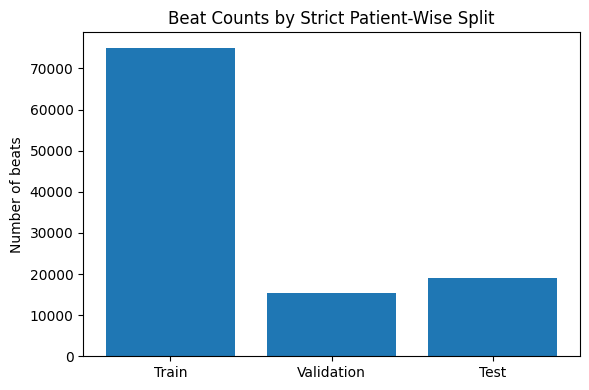

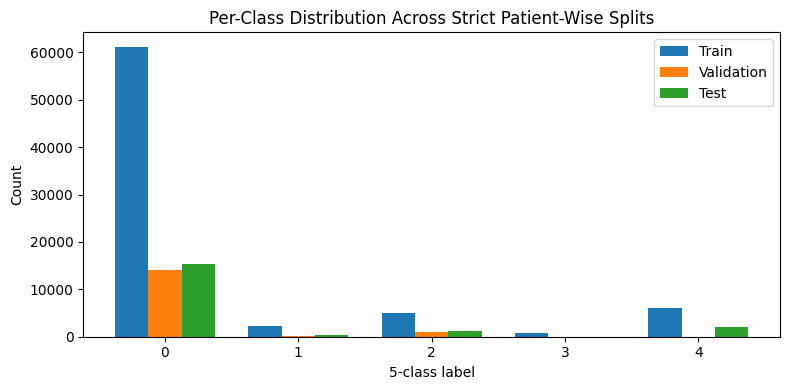

In [14]:
# ==========================================================
# D1 — Strict Patient-Wise Train / Validation / Test Split
# Stratified by patient-group dominant class to avoid
# pathological class collapse in val/test.
# ==========================================================

from sklearn.model_selection import StratifiedGroupKFold

ecg_data = X_all.astype(np.float32)
ecg_label = Y5_all.astype(np.int64)
record_id_array = record_ids_all.astype(str)
patient_group_id_array = patient_group_ids_all.astype(str)

# ----------------------------------------------------------
# Build one row per patient group with dominant label
# ----------------------------------------------------------
group_df = pd.DataFrame({
    "patient_group_id": patient_group_id_array,
    "label": ecg_label
})

group_label_df = (
    group_df.groupby("patient_group_id")["label"]
    .agg(lambda x: int(pd.Series(x).value_counts().idxmax()))
    .reset_index()
    .rename(columns={"label": "dominant_label"})
)

unique_patient_groups = group_label_df["patient_group_id"].to_numpy()
group_dominant_labels = group_label_df["dominant_label"].to_numpy()

print("Unique patient groups:", len(unique_patient_groups))
print("Group dominant-label distribution:")
print(pd.Series(group_dominant_labels).value_counts().sort_index())

# ----------------------------------------------------------
# Stage 1: split into train (≈70%) and temp (≈30%)
# ----------------------------------------------------------
sgkf_stage1 = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)

stage1_splits = list(
    sgkf_stage1.split(
        X=np.zeros(len(unique_patient_groups)),
        y=group_dominant_labels,
        groups=unique_patient_groups
    )
)

# Use first fold as temp, remaining folds as train
train_group_idx, temp_group_idx = stage1_splits[0]

train_groups = unique_patient_groups[train_group_idx]
temp_groups = unique_patient_groups[temp_group_idx]

# ----------------------------------------------------------
# Stage 2: split temp into val and test (≈15% / 15%)
# ----------------------------------------------------------
temp_df = group_label_df[group_label_df["patient_group_id"].isin(temp_groups)].copy()

temp_unique_groups = temp_df["patient_group_id"].to_numpy()
temp_dominant_labels = temp_df["dominant_label"].to_numpy()

# If temp has enough diversity, stratify again; otherwise fallback
can_stratify_temp = (
    len(np.unique(temp_dominant_labels)) >= 2
    and np.min(pd.Series(temp_dominant_labels).value_counts().values) >= 2
    and len(temp_unique_groups) >= 4
)

if can_stratify_temp:
    sgkf_stage2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEED)
    stage2_splits = list(
        sgkf_stage2.split(
            X=np.zeros(len(temp_unique_groups)),
            y=temp_dominant_labels,
            groups=temp_unique_groups
        )
    )
    val_group_idx, test_group_idx = stage2_splits[0]
    val_groups = temp_unique_groups[val_group_idx]
    test_groups = temp_unique_groups[test_group_idx]
else:
    print("Warning: temp patient-group stratification not feasible; using deterministic fallback split.")
    rng = np.random.default_rng(SEED)
    shuffled = np.array(temp_unique_groups, copy=True)
    rng.shuffle(shuffled)
    mid = len(shuffled) // 2
    val_groups = shuffled[:mid]
    test_groups = shuffled[mid:]

# ----------------------------------------------------------
# Masks
# ----------------------------------------------------------
train_mask = np.isin(patient_group_id_array, train_groups)
val_mask = np.isin(patient_group_id_array, val_groups)
test_mask = np.isin(patient_group_id_array, test_groups)

x_train = ecg_data[train_mask]
y_train = ecg_label[train_mask]
train_record_ids = record_id_array[train_mask]
train_patient_groups = patient_group_id_array[train_mask]

x_val = ecg_data[val_mask]
y_val = ecg_label[val_mask]
val_record_ids = record_id_array[val_mask]
val_patient_groups = patient_group_id_array[val_mask]

x_test = ecg_data[test_mask]
y_test = ecg_label[test_mask]
test_record_ids = record_id_array[test_mask]
test_patient_groups = patient_group_id_array[test_mask]

print("Train:", x_train.shape, y_train.shape)
print("Val:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

assert set(train_groups).isdisjoint(set(val_groups))
assert set(train_groups).isdisjoint(set(test_groups))
assert set(val_groups).isdisjoint(set(test_groups))

print("Strict patient-group disjoint split confirmed.")
print("Train patient groups:", len(train_groups))
print("Val patient groups:", len(val_groups))
print("Test patient groups:", len(test_groups))

print("Train records:", sorted(np.unique(train_record_ids)))
print("Val records:", sorted(np.unique(val_record_ids)))
print("Test records:", sorted(np.unique(test_record_ids)))

# ----------------------------------------------------------
# Save split artefacts
# ----------------------------------------------------------
test_df = pd.DataFrame(x_test, columns=[f"x_{i}" for i in range(SEG_LEN)])
test_df["label_5"] = y_test.astype(np.int64)
test_df["record_id"] = test_record_ids.astype(str)
test_df["patient_group_id"] = test_patient_groups.astype(str)
test_df.to_pickle(os.path.join(project_path, "test_data.pkl"))

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "PatientGroups": [len(train_groups), len(val_groups), len(test_groups)],
    "Records": [
        len(np.unique(train_record_ids)),
        len(np.unique(val_record_ids)),
        len(np.unique(test_record_ids))
    ],
    "Beats": [len(x_train), len(x_val), len(x_test)]
})
split_summary.to_csv(os.path.join(METRIC_DIR, "split_summary.csv"), index=False)

plt.figure(figsize=(6, 4))
plt.bar(split_summary["Split"], split_summary["Beats"])
plt.ylabel("Number of beats")
plt.title("Beat Counts by Strict Patient-Wise Split")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "split_beat_counts.png"))
plt.show()

train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts = pd.Series(y_val).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

all_classes = sorted(set(train_counts.index) | set(val_counts.index) | set(test_counts.index))

split_class_df = pd.DataFrame({
    "Class": all_classes,
    "Train": [train_counts.get(c, 0) for c in all_classes],
    "Validation": [val_counts.get(c, 0) for c in all_classes],
    "Test": [test_counts.get(c, 0) for c in all_classes]
})

split_class_df.to_csv(os.path.join(METRIC_DIR, "split_class_distribution.csv"), index=False)

x_pos = np.arange(len(split_class_df["Class"]))
width = 0.25

plt.figure(figsize=(8, 4))
plt.bar(x_pos - width, split_class_df["Train"], width=width, label="Train")
plt.bar(x_pos, split_class_df["Validation"], width=width, label="Validation")
plt.bar(x_pos + width, split_class_df["Test"], width=width, label="Test")
plt.xticks(x_pos, split_class_df["Class"].astype(str))
plt.xlabel("5-class label")
plt.ylabel("Count")
plt.title("Per-Class Distribution Across Strict Patient-Wise Splits")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "split_class_distribution.png"))
plt.show()

## **D2 — Leakage Checks and Split Diagnostics**

In [15]:
# ==========================================================
# D2 — Leakage Checks and Split Diagnostics
# ==========================================================

# ----------------------------------------------------------
# Group / record leakage checks
# ----------------------------------------------------------
train_group_set = set(train_groups)
val_group_set = set(val_groups)
test_group_set = set(test_groups)

train_record_set = set(train_record_ids)
val_record_set = set(val_record_ids)
test_record_set = set(test_record_ids)

print("===== PATIENT-GROUP LEAKAGE CHECK =====")
print("Train groups:", len(train_group_set))
print("Val groups:", len(val_group_set))
print("Test groups:", len(test_group_set))

assert train_group_set.isdisjoint(val_group_set), "Leakage: train and val patient groups overlap"
assert train_group_set.isdisjoint(test_group_set), "Leakage: train and test patient groups overlap"
assert val_group_set.isdisjoint(test_group_set), "Leakage: val and test patient groups overlap"

print("No patient-group leakage detected.")

print("\n===== RECORD LEAKAGE CHECK =====")
assert train_record_set.isdisjoint(val_record_set), "Leakage: train and val records overlap"
assert train_record_set.isdisjoint(test_record_set), "Leakage: train and test records overlap"
assert val_record_set.isdisjoint(test_record_set), "Leakage: val and test records overlap"
print("No record-level leakage detected.")

# ----------------------------------------------------------
# Per-split class distribution diagnostics
# ----------------------------------------------------------
train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts = pd.Series(y_val).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

split_diag_df = pd.DataFrame({
    "Class": np.arange(len(CLASS_NAMES_SHORT)),
    "ClassName": CLASS_NAMES_SHORT,
    "TrainCount": [train_counts.get(i, 0) for i in range(len(CLASS_NAMES_SHORT))],
    "ValCount": [val_counts.get(i, 0) for i in range(len(CLASS_NAMES_SHORT))],
    "TestCount": [test_counts.get(i, 0) for i in range(len(CLASS_NAMES_SHORT))]
})

split_diag_df["TrainPct"] = split_diag_df["TrainCount"] / max(len(y_train), 1)
split_diag_df["ValPct"] = split_diag_df["ValCount"] / max(len(y_val), 1)
split_diag_df["TestPct"] = split_diag_df["TestCount"] / max(len(y_test), 1)

print("\n===== SPLIT DIAGNOSTICS =====")
print(split_diag_df)

split_diag_df.to_csv(
    os.path.join(METRIC_DIR, "split_diagnostics_detailed.csv"),
    index=False
)

# ----------------------------------------------------------
# Plot class distribution across splits
# ----------------------------------------------------------
x_pos = np.arange(len(CLASS_NAMES_SHORT))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x_pos - width, split_diag_df["TrainCount"], width=width, label="Train")
ax.bar(x_pos, split_diag_df["ValCount"], width=width, label="Validation")
ax.bar(x_pos + width, split_diag_df["TestCount"], width=width, label="Test")

ax.set_xticks(x_pos)
ax.set_xticklabels(CLASS_NAMES_SHORT)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Per-Class Distribution Across Strict Patient-Wise Splits")
ax.legend()

plt.tight_layout()
savefig_drive(fig, "split_class_distribution_diagnostics.png")

===== PATIENT-GROUP LEAKAGE CHECK =====
Train groups: 32
Val groups: 7
Test groups: 8
No patient-group leakage detected.

===== RECORD LEAKAGE CHECK =====
No record-level leakage detected.

===== SPLIT DIAGNOSTICS =====
   Class ClassName  TrainCount  ValCount  TestCount  TrainPct    ValPct  \
0      0         N       61150     14156      15283  0.814996  0.920895   
1      1         S        2183       195        403  0.029095  0.012685   
2      2         V        4958      1013       1264  0.066079  0.065899   
3      3         F         769         6         27  0.010249  0.000390   
4      4         Q        5971         2       2066  0.079580  0.000130   

    TestPct  
0  0.802552  
1  0.021163  
2  0.066376  
3  0.001418  
4  0.108491  
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/split_class_distribution_diagnostics.png


## **D3 — Training Set Balancing by Undersampling and SMOTE**

Imbalanced training distribution:
0    61150
1     2183
2     4958
3      769
4     5971
Name: count, dtype: int64


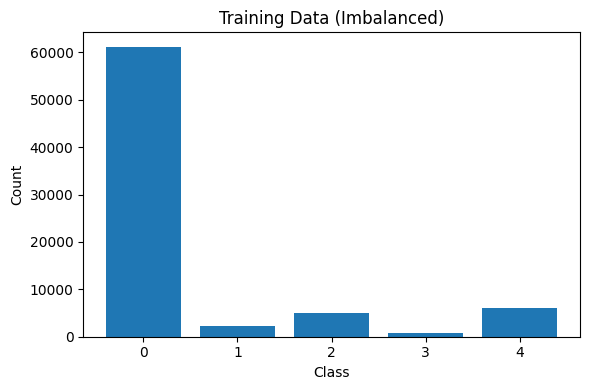

Chosen target_per_class: 5971
SMOTE k_neighbors: 5
Balanced training distribution:
0    5971
1    5971
2    5971
3    5971
4    5971
Name: count, dtype: int64


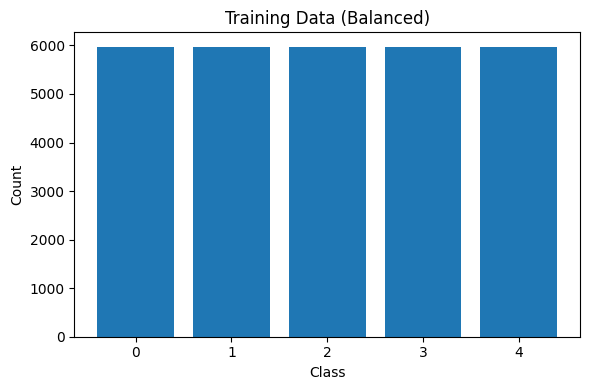

Balanced training data saved to: /content/data/mitdb/train_data_SMOTE.pkl
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/Class_balancing.png
x_train_balanced shape: (29855, 300)
y_train_balanced shape: (29855,)


In [16]:
# ==========================================================
# D3 — Training Set Balancing by Undersampling and SMOTE
# Training data only
# IMPORTANT:
# Resampling is applied ONLY to the training split after
# strict patient-wise splitting. Validation and test sets
# remain untouched to preserve unbiased evaluation.
#
# This block restores the stronger V4-style balancing regime:
#   - majority class undersampled aggressively
#   - minority classes SMOTE-upsampled to the same target
# ==========================================================

from imblearn.over_sampling import SMOTE

X_train_raw = x_train.astype(np.float32)
y_train_raw = y_train.astype(np.int64).reshape(-1)

class_counts_before = pd.Series(y_train_raw).value_counts().sort_index()
print("Imbalanced training distribution:")
print(class_counts_before)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(class_counts_before.index.astype(int), class_counts_before.values)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Training Data (Imbalanced)")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# V4-style aggressive target size
# In V4, each class was pushed to 50,000.
# Keep that behaviour, but never exceed majority count.
# ----------------------------------------------------------
majority_class = 0
majority_count = int(np.sum(y_train_raw == majority_class))

TARGET_PER_CLASS_V4_STYLE = 50000
target_per_class = min(TARGET_PER_CLASS_V4_STYLE, majority_count)

print("Chosen target_per_class:", target_per_class)

# ----------------------------------------------------------
# Split majority vs minority
# ----------------------------------------------------------
idx_majority = np.where(y_train_raw == majority_class)[0]
idx_other = np.where(y_train_raw != majority_class)[0]

rng = np.random.default_rng(SEED)

if target_per_class < len(idx_majority):
    idx_majority_keep = rng.choice(idx_majority, size=target_per_class, replace=False)
else:
    idx_majority_keep = idx_majority.copy()

X_majority = X_train_raw[idx_majority_keep]
y_majority = y_train_raw[idx_majority_keep]

X_other = X_train_raw[idx_other]
y_other = y_train_raw[idx_other]

# ----------------------------------------------------------
# SMOTE minority classes up to target_per_class
# ----------------------------------------------------------
other_class_counts = pd.Series(y_other).value_counts().sort_index()
print("Minority-class distribution before SMOTE:")
print(other_class_counts)

min_other_count = int(other_class_counts.min())
if min_other_count < 2:
    raise ValueError(
        "At least one minority class in y_other has fewer than 2 samples; "
        "SMOTE cannot be applied safely."
    )

smote_k = min(5, min_other_count - 1)

smote_strategy = {
    int(c): int(target_per_class)
    for c in sorted(np.unique(y_other))
    if np.sum(y_other == c) < target_per_class
}

print("SMOTE strategy:", smote_strategy)
print("SMOTE k_neighbors:", smote_k)

smote = SMOTE(
    sampling_strategy=smote_strategy,
    random_state=SEED,
    k_neighbors=smote_k
)

X_other_resampled, y_other_resampled = smote.fit_resample(X_other, y_other)

# ----------------------------------------------------------
# Combine and shuffle
# ----------------------------------------------------------
x_train_balanced = np.vstack([X_majority, X_other_resampled]).astype(np.float32)
y_train_balanced = np.concatenate([y_majority, y_other_resampled]).astype(np.int64)

perm = rng.permutation(len(y_train_balanced))
x_train_balanced = x_train_balanced[perm]
y_train_balanced = y_train_balanced[perm]

class_counts_after = pd.Series(y_train_balanced).value_counts().sort_index()
print("Balanced training distribution:")
print(class_counts_after)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(class_counts_after.index.astype(int), class_counts_after.values)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Training Data (Balanced)")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Save balanced training artefact
# ----------------------------------------------------------
train_data_r = pd.DataFrame(x_train_balanced)
train_data_r[SEG_LEN] = y_train_balanced
train_data_smote_path = os.path.join(project_path, "train_data_SMOTE.pkl")
train_data_r.to_pickle(train_data_smote_path)

print(f"Balanced training data saved to: {train_data_smote_path}")

# ----------------------------------------------------------
# Comparison figure
# ----------------------------------------------------------
fig = plt.figure(figsize=(8, 4), dpi=300)

plt.subplot(1, 2, 1)
sns.barplot(x=['N', 'S', 'V', 'F', 'Q'], y=class_counts_before.sort_index().values)
plt.ylim(0, max(class_counts_before.max(), class_counts_after.max()) * 1.05)
plt.title("Training Data (Imbalanced)")
plt.xlabel("Class")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.barplot(x=['N', 'S', 'V', 'F', 'Q'], y=class_counts_after.sort_index().values)
plt.ylim(0, max(class_counts_before.max(), class_counts_after.max()) * 1.05)
plt.title("Balanced by Undersampling + SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
savefig_drive(fig, "Class_balancing.png")

print("x_train_balanced shape:", x_train_balanced.shape)
print("y_train_balanced shape:", y_train_balanced.shape)

# **E — Model Architecture & Training**

In [17]:
# ==========================================================
# Part E — Canonical CNN-LSTM with Channel + Spatial Attention
# V4-strength training regime, V5-safe loading / saving
# ==========================================================

class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, filters, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):
        hidden_units = max(1, self.filters // self.ratio)

        self.shared_layer_one = tf.keras.layers.Dense(
            hidden_units,
            activation="relu",
            kernel_initializer="he_normal",
            use_bias=True
        )
        self.shared_layer_two = tf.keras.layers.Dense(
            self.filters,
            kernel_initializer="he_normal",
            use_bias=True
        )

    def call(self, inputs):
        avg_pool = tf.keras.layers.GlobalAveragePooling1D()(inputs)
        avg_pool = self.shared_layer_one(avg_pool)
        avg_pool = self.shared_layer_two(avg_pool)

        max_pool = tf.keras.layers.GlobalMaxPooling1D()(inputs)
        max_pool = self.shared_layer_one(max_pool)
        max_pool = self.shared_layer_two(max_pool)

        attention = tf.keras.layers.Add()([avg_pool, max_pool])
        attention = tf.keras.layers.Activation("sigmoid")(attention)
        attention = tf.keras.layers.Reshape((1, self.filters))(attention)

        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "ratio": self.ratio
        })
        return config


class SpatialAttention1D(tf.keras.layers.Layer):
    """
    Proper 1D spatial attention.
    Operates over the temporal axis, unlike the broken V4 Conv2D version.
    """
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv = tf.keras.layers.Conv1D(
            filters=1,
            kernel_size=self.kernel_size,
            strides=1,
            padding="same",
            activation="sigmoid",
            kernel_initializer="he_normal",
            use_bias=False
        )

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        attention = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(attention)
        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({
            "kernel_size": self.kernel_size
        })
        return config


def build_model():
    inputs = tf.keras.layers.Input(shape=(300, 1), name="ecg_input")

    x = tf.keras.layers.Conv1D(
        16, 21, padding="same", activation="relu", name="conv1"
    )(inputs)
    x = ChannelAttention(16, 8, name="ca1")(x)
    x = tf.keras.layers.MaxPool1D(
        pool_size=3, strides=2, padding="same", name="pool1"
    )(x)

    x = tf.keras.layers.Conv1D(
        32, 23, padding="same", activation="relu", name="conv2"
    )(x)
    x = ChannelAttention(32, 8, name="ca2")(x)
    x = tf.keras.layers.MaxPool1D(
        pool_size=3, strides=2, padding="same", name="pool2"
    )(x)

    x = tf.keras.layers.Conv1D(
        64, 25, padding="same", activation="relu", name="conv3"
    )(x)
    x = ChannelAttention(64, 8, name="ca3")(x)
    x = tf.keras.layers.AvgPool1D(
        pool_size=3, strides=2, padding="same", name="pool3"
    )(x)

    x = tf.keras.layers.Conv1D(
        128, 27, padding="same", activation="relu", name="final_conv"
    )(x)
    x = ChannelAttention(128, 8, name="ca4")(x)
    x = SpatialAttention1D(kernel_size=7, name="sa4")(x)

    # Restore the stronger V4-style recurrent stack
    x = tf.keras.layers.LSTM(64, return_sequences=True, name="lstm1")(x)
    x = tf.keras.layers.Dropout(0.2, name="dropout1")(x)
    x = tf.keras.layers.LSTM(32, return_sequences=True, name="lstm2")(x)
    x = tf.keras.layers.Flatten(name="flatten")(x)

    x = tf.keras.layers.Dense(128, activation="relu", name="embedding_dense")(x)
    x = tf.keras.layers.Dropout(0.2, name="dropout2")(x)

    outputs = tf.keras.layers.Dense(5, activation="softmax", name="classifier")(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="cnn_lstm_channel_spatial_attention_ecg"
    )


def is_canonical_model(model):
    required_layers = {
        "final_conv",
        "embedding_dense",
        "classifier",
        "ca1", "ca2", "ca3", "ca4",
        "sa4",
        "lstm1", "lstm2"
    }
    present = {layer.name for layer in model.layers}
    return required_layers.issubset(present)


# ----------------------------------------------------------
# Prepare arrays
# ----------------------------------------------------------
X_train = x_train_balanced.reshape(-1, 300, 1).astype(np.float32)
Y_train = flatten_labels(y_train_balanced)

X_val = x_val.reshape(-1, 300, 1).astype(np.float32)
Y_val = flatten_labels(y_val)

X_test = x_test.reshape(-1, 300, 1).astype(np.float32)
Y_test = flatten_labels(y_test)

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val:", X_val.shape, "Y_val:", Y_val.shape)
print("X_test:", X_test.shape, "Y_test:", Y_test.shape)

MODEL_NAME = "ecg_model_patientwise_balanced_attention_v3.keras"
WEIGHTS_NAME = "best_weights_patientwise_balanced_attention_v3.weights.h5"

MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)
CHECKPOINT_PATH = os.path.join(MODEL_DIR, WEIGHTS_NAME)

history = None
load_ok = False

# ----------------------------------------------------------
# Try loading canonical saved model only
# ----------------------------------------------------------
if os.path.exists(MODEL_PATH):
    try:
        candidate_model = tf.keras.models.load_model(
            MODEL_PATH,
            custom_objects={
                "ChannelAttention": ChannelAttention,
                "SpatialAttention1D": SpatialAttention1D
            }
        )
        if is_canonical_model(candidate_model):
            model = candidate_model
            load_ok = True
            print("Loaded canonical saved model.")
        else:
            print("Saved model exists but is not canonical. It will be ignored and retrained.")
    except Exception as e:
        print("Could not load saved model safely:", e)

# ----------------------------------------------------------
# Otherwise build and optionally load canonical weights
# ----------------------------------------------------------
if not load_ok:
    model = build_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    if os.path.exists(CHECKPOINT_PATH):
        try:
            model.load_weights(CHECKPOINT_PATH)
            load_ok = True
            print("Loaded canonical checkpoint weights.")
        except Exception as e:
            print("Checkpoint exists but could not be loaded:", e)

# ----------------------------------------------------------
# Train only if no valid canonical artefact could be loaded
# ----------------------------------------------------------
if not load_ok:
    print("Training canonical model from scratch...")

    logdir = os.path.join(
        project_path,
        "logs",
        datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    )

    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=logdir,
        histogram_freq=1
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        save_weights_only=True,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )

    history = model.fit(
        X_train,
        Y_train,
        epochs=40,
        batch_size=128,
        validation_data=(X_val, Y_val),
        callbacks=[
            tensorboard_callback,
            early_stopping,
            reduce_lr,
            model_checkpoint_callback
        ],
        verbose=1
    )

    # Explicitly reload best checkpoint to guarantee best-val model
    if os.path.exists(CHECKPOINT_PATH):
        model.load_weights(CHECKPOINT_PATH)
        print("Reloaded best checkpoint weights after training.")

    model.save(MODEL_PATH)
    print("Saved canonical model to:", MODEL_PATH)
else:
    print("Using existing canonical model artefact.")

# ----------------------------------------------------------
# Final safety check
# ----------------------------------------------------------
assert is_canonical_model(model), "Loaded/trained model is not the canonical dissertation architecture."

print("Canonical model ready.")
model.summary()

try:
    tf.keras.utils.plot_model(
        model,
        to_file=os.path.join(FIG_DIR, "model_architecture.png"),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=True
    )
    print("Model architecture figure saved.")
except Exception as e:
    print("Could not save model architecture figure:", e)

X_train: (29855, 300, 1) Y_train: (29855,)
X_val: (15372, 300, 1) Y_val: (15372,)
X_test: (19043, 300, 1) Y_test: (19043,)
Training canonical model from scratch...
Epoch 1/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 131s 484ms/step - accuracy: 0.8073 - loss: 0.5465 - val_accuracy: 0.5930 - val_loss: 1.4080
Epoch 2/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 113s 483ms/step - accuracy: 0.9166 - loss: 0.2475 - val_accuracy: 0.7335 - val_loss: 0.7384
Epoch 3/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 108s 461ms/step - accuracy: 0.9355 - loss: 0.1922 - val_accuracy: 0.7760 - val_loss: 0.7516
Epoch 4/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 108s 464ms/step - accuracy: 0.9469 - loss: 0.1524 - val_accuracy: 0.8562 - val_loss: 0.5451
Epoch 5/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 149s 496ms/step - accuracy: 0.9569 - loss: 0.1274 - val_accuracy: 0.8119 - val_loss: 0.7335
Epoch 6/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 144s 503ms/step - accuracy: 0.9644 - loss: 0.1016 - val_accuracy: 0.8433 - val_loss: 0.6197
Epoch 7/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 110s

Model: "cnn_lstm_channel_attention_ecg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)          │ (None, 300, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 300, 16)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ca1 (ChannelAttention)          │ (None, 300, 16)        │            82 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 150, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 150, 32)        │        11,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ca2 (ChannelAttention)          │ (None, 150, 32)        │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 75, 64)         │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ca3 (ChannelAttention)          │ (None, 75, 64)         │         1,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (AveragePooling1D)        │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_conv (Conv1D)             │ (None, 38, 128)        │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ca4 (ChannelAttention)          │ (None, 38, 128)        │         4,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 38, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dense (Dense)         │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,419 (4.09 MB)

 Trainable params: 357,139 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 714,280 (2.72 MB)

Model architecture figure saved.


In [18]:
# ==========================================================
# Training curves
# ==========================================================

if history is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history.history["accuracy"], label="Train accuracy")
    ax.plot(history.history["val_accuracy"], label="Validation accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("Training and Validation Accuracy")
    ax.legend()
    plt.tight_layout()
    savefig_drive(fig, "training_validation_accuracy.png")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history.history["loss"], label="Train loss")
    ax.plot(history.history["val_loss"], label="Validation loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training and Validation Loss")
    ax.legend()
    plt.tight_layout()
    savefig_drive(fig, "training_validation_loss.png")
else:
    print("Model loaded from saved canonical artefact — no new training history available.")

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/training_validation_accuracy.png
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/training_validation_loss.png


# **F — Calibration (Temperature Scaling + ECE)**

In [19]:
# ==========================================================
# F — Calibration (Temperature Scaling + ECE)
# Split validation patient groups into:
#   (1) temperature-fit partition
#   (2) conformal-calibration partition
# ==========================================================

from scipy.optimize import minimize
from tensorflow.keras.models import Model

# ----------------------------------------------------------
# Ensure model graph is built
# ----------------------------------------------------------
_ = model.predict(X_val[:1], verbose=0)

# ----------------------------------------------------------
# Split validation by patient group, not record
# ----------------------------------------------------------
val_patient_groups_full = val_patient_groups.astype(str)
unique_val_patient_groups = np.unique(val_patient_groups_full)

val_temp_groups, val_conf_groups = train_test_split(
    unique_val_patient_groups,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

temp_mask = np.isin(val_patient_groups_full, val_temp_groups)
conf_mask = np.isin(val_patient_groups_full, val_conf_groups)

X_val_temp = X_val[temp_mask]
y_val_temp = Y_val[temp_mask]

X_val_conf = X_val[conf_mask]
y_val_conf = Y_val[conf_mask]

print("Temperature-scaling set:", X_val_temp.shape, y_val_temp.shape)
print("Conformal-calibration set:", X_val_conf.shape, y_val_conf.shape)

assert len(X_val_temp) > 0 and len(X_val_conf) > 0, "Validation split for calibration/conformal is empty."
assert set(val_temp_groups).isdisjoint(set(val_conf_groups)), "Validation patient-group partitions overlap."

# ----------------------------------------------------------
# Build logits model from classifier weights
# ----------------------------------------------------------
classifier_layer = model.get_layer("classifier")
classifier_input = classifier_layer.input

logits_output = tf.keras.layers.Dense(
    units=classifier_layer.units,
    activation=None,
    use_bias=True,
    name="logits_layer"
)(classifier_input)

logits_model = Model(inputs=model.inputs, outputs=logits_output)
logits_model.get_layer("logits_layer").set_weights(classifier_layer.get_weights())

def get_logits(x):
    x = np.asarray(x, dtype=np.float32)
    return logits_model.predict(x, batch_size=256, verbose=0)

def softmax_np(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

labels_temp = flatten_labels(y_val_temp)
logits_temp = get_logits(X_val_temp)

def temperature_nll(T, logits, labels):
    T = float(T[0])
    logits_T = logits / T
    probs = softmax_np(logits_T)
    nll = -np.log(probs[np.arange(len(labels)), labels] + 1e-12)
    return float(np.mean(nll))

opt = minimize(
    temperature_nll,
    x0=[1.0],
    args=(logits_temp, labels_temp),
    bounds=[(0.05, 10.0)]
)

T_star = float(opt.x[0])
print("Optimal temperature:", T_star)

def predict_proba_calibrated(x):
    logits = get_logits(x)
    logits = logits / T_star
    return softmax_np(logits)

# ----------------------------------------------------------
# Evaluate calibration on held-out test set
# ----------------------------------------------------------
labels_test = flatten_labels(Y_test)

probs_uncal = model.predict(X_test, batch_size=256, verbose=0)
probs_cal = predict_proba_calibrated(X_test)

ece_uncal = compute_ece(probs_uncal, labels_test)
ece_cal = compute_ece(probs_cal, labels_test)

acc_uncal = float(np.mean(np.argmax(probs_uncal, axis=1) == labels_test))
acc_cal = float(np.mean(np.argmax(probs_cal, axis=1) == labels_test))

brier_uncal = macro_brier_score(labels_test, probs_uncal, num_classes=5)
brier_cal = macro_brier_score(labels_test, probs_cal, num_classes=5)

nll_uncal = float(log_loss(labels_test, probs_uncal))
nll_cal = float(log_loss(labels_test, probs_cal))

print("ECE before calibration:", ece_uncal)
print("ECE after calibration:", ece_cal)
print("Brier before calibration:", brier_uncal)
print("Brier after calibration:", brier_cal)
print("NLL before calibration:", nll_uncal)
print("NLL after calibration:", nll_cal)
print("Accuracy before calibration:", acc_uncal)
print("Accuracy after calibration:", acc_cal)

# ----------------------------------------------------------
# Reliability diagram before/after calibration
# ----------------------------------------------------------
conf_uncal_curve, acc_uncal_curve = reliability_curve_points(probs_uncal, labels_test, n_bins=10)
conf_cal_curve, acc_cal_curve = reliability_curve_points(probs_cal, labels_test, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(conf_uncal_curve, acc_uncal_curve, marker="o", label="Uncalibrated")
ax.plot(conf_cal_curve, acc_cal_curve, marker="o", label="Calibrated")
ax.plot([0, 1], [0, 1], "--", label="Perfect calibration")
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Calibration Comparison")
ax.legend()
plt.tight_layout()
savefig_drive(fig, "calibration_comparison.png")

calibration_metrics = pd.DataFrame({
    "Metric": [
        "Temperature",
        "ECE_before",
        "ECE_after",
        "Brier_before",
        "Brier_after",
        "NLL_before",
        "NLL_after",
        "Accuracy_before",
        "Accuracy_after"
    ],
    "Value": [
        T_star,
        ece_uncal,
        ece_cal,
        brier_uncal,
        brier_cal,
        nll_uncal,
        nll_cal,
        acc_uncal,
        acc_cal
    ]
})

calibration_metrics.to_csv(
    os.path.join(METRIC_DIR, "calibration_metrics.csv"),
    index=False
)

print(calibration_metrics)

print("Logits variance:", np.var(logits_temp))
print("Confidence mean:", np.mean(np.max(softmax_np(logits_temp), axis=1)))

Temperature-scaling set: (7529, 300, 1) (7529,)
Conformal-calibration set: (7843, 300, 1) (7843,)
Optimal temperature: 1.0
ECE before calibration: 0.15636853220576352
ECE after calibration: 0.15636854596056113
Brier before calibration: 0.08733836379956424
Brier after calibration: 0.08733836475706315
NLL before calibration: 1.2307557756729355
NLL after calibration: 1.230755764433903
Accuracy before calibration: 0.7317649530011028
Accuracy after calibration: 0.7317649530011028
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/calibration_comparison.png
            Metric     Value
0      Temperature  1.000000
1       ECE_before  0.156369
2        ECE_after  0.156369
3     Brier_before  0.087338
4      Brier_after  0.087338
5       NLL_before  1.230756
6        NLL_after  1.230756
7  Accuracy_before  0.731765
8   Accuracy_after  0.731765
Logits variance: 8.512847
Confidence mean: 0.91900635


# **G — Uncertainty Modelling (Conformal Prediction)**

In [20]:
# ==========================================================
# G — Uncertainty Modelling (Conformal Prediction)
# ==========================================================

alpha = 0.10  # target 90% coverage

labels_conf = flatten_labels(y_val_conf)
conf_probs = predict_proba_calibrated(X_val_conf)

conf_scores = 1.0 - conf_probs[np.arange(len(labels_conf)), labels_conf]

n_conf = len(conf_scores)
quantile_level = np.ceil((n_conf + 1) * (1 - alpha)) / n_conf
quantile_level = min(1.0, quantile_level)

qhat = np.quantile(conf_scores, quantile_level, method="higher")

print("Conformal threshold qhat:", qhat)
print("Quantile level used:", quantile_level)

def conformal_prediction_set(x):
    probs = predict_proba_calibrated(x)
    prediction_sets = []

    for p in probs:
        scores = 1.0 - p
        indices = np.where(scores <= qhat)[0]

        if len(indices) == 0:
            indices = np.array([np.argmax(p)])

        prediction_sets.append(indices)

    return prediction_sets

test_sets = conformal_prediction_set(X_test)
true_test = flatten_labels(Y_test)

covered = np.array([true_test[i] in test_sets[i] for i in range(len(true_test))], dtype=bool)
set_sizes = np.array([len(s) for s in test_sets])

empirical_coverage = float(np.mean(covered))
mean_set_size = float(np.mean(set_sizes))
singleton_rate = float(np.mean(set_sizes == 1))
ambiguity_rate = float(np.mean(set_sizes > 1))

print("Empirical test coverage:", empirical_coverage)
print("Mean prediction set size:", mean_set_size)
print("Singleton rate:", singleton_rate)
print("Ambiguity rate:", ambiguity_rate)

conformal_metrics = pd.DataFrame({
    "Metric": ["EmpiricalCoverage", "MeanSetSize", "SingletonRate", "AmbiguityRate", "Qhat"],
    "Value": [empirical_coverage, mean_set_size, singleton_rate, ambiguity_rate, float(qhat)]
})
conformal_metrics.to_csv(os.path.join(METRIC_DIR, "conformal_metrics.csv"), index=False)

fig, ax = plt.subplots(figsize=(6, 4))
unique_sizes, counts = np.unique(set_sizes, return_counts=True)
ax.bar(unique_sizes.astype(str), counts)
ax.set_xlabel("Prediction set size")
ax.set_ylabel("Count")
ax.set_title("Distribution of Conformal Prediction Set Sizes")
plt.tight_layout()
savefig_drive(fig, "conformal_set_size_distribution.png")

Conformal threshold qhat: 0.94031185
Quantile level used: 0.9001657529006758
Empirical test coverage: 0.8129496402877698
Mean prediction set size: 1.4431024523446936
Singleton rate: 0.600273066218558
Ambiguity rate: 0.399726933781442
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/conformal_set_size_distribution.png


# **H — Evaluation & Performance Analysis**

In [21]:
# ==========================================================
# UNIFIED EVALUATION BLOCK — canonical dissertation version
# ==========================================================

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

Y_test_flat = flatten_labels(Y_test)

# ----------------------------------------------------------
# Baselines
# ----------------------------------------------------------
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

maj = DummyClassifier(strategy="most_frequent")
maj.fit(X_train_flat, Y_train)
maj_pred = maj.predict(X_test_flat)
maj_probs = maj.predict_proba(X_test_flat)

logreg = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
logreg.fit(X_train_flat, Y_train)
lr_pred = logreg.predict(X_test_flat)
lr_probs = logreg.predict_proba(X_test_flat)

def summarise_model(name, y_true, y_pred, probs):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "MacroPrecision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "MacroRecall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "MacroF1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ECE": compute_ece(probs, y_true)
    }

# ----------------------------------------------------------
# CNN predictions
# ----------------------------------------------------------
probs_uncal = model.predict(X_test, batch_size=256, verbose=0)
preds_uncal = np.argmax(probs_uncal, axis=1)

probs_cal = predict_proba_calibrated(X_test)
preds_cal = np.argmax(probs_cal, axis=1)

# ----------------------------------------------------------
# Classifier summary table
# ----------------------------------------------------------
classifier_metrics = pd.DataFrame([
    summarise_model("Majority", Y_test_flat, maj_pred, maj_probs),
    summarise_model("LogisticRegression", Y_test_flat, lr_pred, lr_probs),
    {
        "Model": "CNN-LSTM Uncalibrated",
        "Accuracy": accuracy_score(Y_test_flat, preds_uncal),
        "MacroPrecision": precision_score(Y_test_flat, preds_uncal, average="macro", zero_division=0),
        "MacroRecall": recall_score(Y_test_flat, preds_uncal, average="macro", zero_division=0),
        "MacroF1": f1_score(Y_test_flat, preds_uncal, average="macro", zero_division=0),
        "ECE": compute_ece(probs_uncal, Y_test_flat)
    },
    {
        "Model": "CNN-LSTM Calibrated",
        "Accuracy": accuracy_score(Y_test_flat, preds_cal),
        "MacroPrecision": precision_score(Y_test_flat, preds_cal, average="macro", zero_division=0),
        "MacroRecall": recall_score(Y_test_flat, preds_cal, average="macro", zero_division=0),
        "MacroF1": f1_score(Y_test_flat, preds_cal, average="macro", zero_division=0),
        "ECE": compute_ece(probs_cal, Y_test_flat)
    }
])

classifier_metrics["ROC_AUC_OVR"] = np.nan
classifier_metrics["Brier"] = np.nan
classifier_metrics["NLL"] = np.nan

classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Uncalibrated", "ROC_AUC_OVR"] = roc_auc_score(Y_test_flat, probs_uncal, multi_class="ovr")
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Uncalibrated", "Brier"] = macro_brier_score(Y_test_flat, probs_uncal, num_classes=5)
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Uncalibrated", "NLL"] = log_loss(Y_test_flat, probs_uncal)

classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Calibrated", "ROC_AUC_OVR"] = roc_auc_score(Y_test_flat, probs_cal, multi_class="ovr")
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Calibrated", "Brier"] = macro_brier_score(Y_test_flat, probs_cal, num_classes=5)
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Calibrated", "NLL"] = log_loss(Y_test_flat, probs_cal)

classifier_metrics.to_csv(os.path.join(METRIC_DIR, "classifier_metrics_unified.csv"), index=False)
with open(os.path.join(TAB_DIR, "classifier_metrics_unified.tex"), "w") as f:
    f.write(classifier_metrics.to_latex(index=False, float_format="%.4f"))

print(classifier_metrics)

# ----------------------------------------------------------
# Per-class metrics on calibrated predictions
# ----------------------------------------------------------
per_class_df = per_class_metrics_dataframe(Y_test_flat, preds_cal, class_names=CLASS_NAMES_SHORT)
per_class_df.to_csv(os.path.join(METRIC_DIR, "per_class_metrics_calibrated.csv"), index=False)

with open(os.path.join(TAB_DIR, "per_class_metrics_calibrated.tex"), "w") as f:
    f.write(per_class_df.to_latex(index=False, float_format="%.4f"))

print(per_class_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(per_class_df["Class"], per_class_df["F1"])
ax.set_xlabel("Class")
ax.set_ylabel("F1")
ax.set_title("Per-Class F1 Scores (Calibrated CNN-LSTM)")
plt.tight_layout()
savefig_drive(fig, "per_class_f1_scores.png")

# ----------------------------------------------------------
# Confusion matrix
# ----------------------------------------------------------
cm = confusion_matrix(Y_test_flat, preds_cal, labels=np.arange(5))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_NAMES_SHORT,
    yticklabels=CLASS_NAMES_SHORT,
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Calibrated CNN-LSTM)")
plt.tight_layout()
savefig_drive(fig, "confusion_matrix_calibrated.png")

                   Model  Accuracy  MacroPrecision  MacroRecall   MacroF1  \
0               Majority  0.802552        0.160510     0.200000  0.178092   
1     LogisticRegression  0.634931        0.359199     0.431165  0.358359   
2  CNN-LSTM Uncalibrated  0.731765        0.440639     0.466290  0.426093   
3    CNN-LSTM Calibrated  0.731765        0.440639     0.466290  0.426093   

        ECE  ROC_AUC_OVR     Brier       NLL  
0  0.197448          NaN       NaN       NaN  
1  0.152860          NaN       NaN       NaN  
2  0.156369      0.75248  0.087338  1.230756  
3  0.156369      0.75248  0.087338  1.230756  
  Class  Sensitivity  Specificity  Precision        F1  PerClassAccuracy  \
0     N     0.758621     0.691489   0.909048  0.827050          0.745366   
1     S     0.166253     0.952307   0.070084  0.098602          0.935672   
2     V     0.599684     0.884920   0.270328  0.372665          0.865988   
3     F     0.074074     0.950778   0.002132  0.004145          0.949535   

# **I — Explainability (Grad-CAM)**

In [22]:
# ==========================================================
# Part I — Explainability: 1D Grad-CAM
# ==========================================================

_ = model.predict(X_test[:1], verbose=0)

GRADCAM_TARGET_LAYER = "final_conv"

gradcam_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(GRADCAM_TARGET_LAYER).output,
        model.output
    ]
)

def gradcam_1d(signal, class_idx=None):
    signal = np.asarray(signal, dtype=np.float32)

    if signal.ndim == 1:
        signal = signal.reshape(1, 300, 1)
    elif signal.ndim == 2:
        signal = signal[np.newaxis, :, :]

    signal = tf.convert_to_tensor(signal)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = gradcam_model(signal, training=False)
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        class_score = predictions[:, class_idx]

    grads = tape.gradient(class_score, conv_outputs)
    if grads is None:
        raise RuntimeError("Grad-CAM gradient computation failed.")

    pooled_grads = tf.reduce_mean(grads, axis=1)[0]
    conv_outputs = conv_outputs[0]

    cam = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    cam = tf.nn.relu(cam).numpy()

    if np.max(cam) > 0:
        cam = cam / np.max(cam)

    cam_resized = np.interp(
        np.linspace(0, len(cam) - 1, 300),
        np.arange(len(cam)),
        cam
    )

    return cam_resized

def plot_ecg_gradcam(ecg, importance_map, title="ECG with 1D Grad-CAM", filename="gradcam_ecg_example.png"):
    ecg = np.asarray(ecg).flatten()
    importance_map = np.asarray(importance_map).flatten()

    if np.max(importance_map) > 0:
        importance_map = importance_map / np.max(importance_map)

    t = np.arange(len(ecg))
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.imshow(
        importance_map[np.newaxis, :],
        cmap="hot",
        aspect="auto",
        extent=[0, len(ecg), np.min(ecg), np.max(ecg)],
        alpha=0.5
    )
    ax.plot(t, ecg, color="black", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")

    plt.tight_layout()
    savefig_drive(fig, filename)

sample = X_test[0].flatten()
cam = gradcam_1d(sample)
plot_ecg_gradcam(sample, cam, title="Example ECG with 1D Grad-CAM", filename="gradcam_ecg_example.png")

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/gradcam_ecg_example.png


# **J — Prototype-Based Explanation**

In [23]:
# ==========================================================
# Part J — Prototype retrieval (reproducible sampled bank)
# ==========================================================

from tensorflow.keras.models import Model
from sklearn.metrics.pairwise import cosine_similarity

embedding_model = Model(
    inputs=model.inputs,
    outputs=model.get_layer("embedding_dense").output
)

print("Embedding dimension:", embedding_model.output_shape)

PROTOTYPE_BANK_SIZE = 5000
rng = np.random.default_rng(SEED)

train_labels_flat = flatten_labels(Y_train)
bank_size = min(PROTOTYPE_BANK_SIZE, len(X_train))

# reproducible random subset, not just first N samples
bank_indices = rng.choice(len(X_train), size=bank_size, replace=False)

X_bank = X_train[bank_indices]
y_bank = train_labels_flat[bank_indices]

print("Prototype bank size:", X_bank.shape)

def compute_embeddings(x):
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    emb = embedding_model(x, training=False).numpy()
    norm = np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8
    return emb / norm

emb_bank = compute_embeddings(X_bank)
print("Embedding bank shape:", emb_bank.shape)

def retrieve_topk(signal, k=3):
    signal = np.asarray(signal, dtype=np.float32)

    if signal.ndim == 1:
        signal = signal.reshape(1, 300, 1)
    elif signal.ndim == 2:
        signal = signal[np.newaxis, :, :]

    query_emb = compute_embeddings(signal)
    sim = cosine_similarity(query_emb, emb_bank)[0]
    idx = np.argsort(sim)[-k:][::-1]

    return {
        "indices": bank_indices[idx],
        "signals": X_bank[idx],
        "labels": y_bank[idx],
        "similarities": sim[idx]
    }

def plot_prototypes(query_signal, result, filename="prototype_retrieval_example.png"):
    k = len(result["signals"])
    fig = plt.figure(figsize=(10, 3 * (k + 1)))

    plt.subplot(k + 1, 1, 1)
    plt.plot(query_signal.flatten(), color="black")
    plt.title("Query ECG")
    plt.ylabel("Amplitude")

    for i in range(k):
        plt.subplot(k + 1, 1, i + 2)
        plt.plot(result["signals"][i].flatten())
        plt.title(
            f"Prototype {i+1} | label={CLASS_NAMES_SHORT[int(result['labels'][i])]} | "
            f"similarity={result['similarities'][i]:.4f}"
        )
        plt.ylabel("Amplitude")

    plt.xlabel("Sample")
    plt.tight_layout()
    savefig_drive(fig, filename)

sample = X_test[0].flatten()
retrieval = retrieve_topk(sample, k=3)
plot_prototypes(sample, retrieval, filename="prototype_retrieval_example.png")

Embedding dimension: (None, 128)
Prototype bank size: (5000, 300, 1)
Embedding bank shape: (5000, 128)
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/prototype_retrieval_example.png


# **K — Robustness Testing (Noise Stress)**

In [24]:
# ==========================================================
# Part K — Robustness testing with performance + reliability metrics
# ==========================================================

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(SEED)

noise_types = {
    "baseline_wander": "bw",
    "muscle_artifact": "ma",
    "electrode_motion": "em"
}

noise_signals = {}
for name, record in noise_types.items():
    signal, _ = wfdb.rdsamp(record, pn_dir="nstdb")
    noise = signal[:, 0]
    noise = (noise - np.mean(noise)) / (np.std(noise) + 1e-8)
    noise_signals[name] = noise

print("Loaded NSTDB noises:", list(noise_signals.keys()))

def add_noise(signal, noise_segment, snr_db):
    signal = signal.flatten()
    noise_segment = noise_segment[:len(signal)]

    signal_rms = np.sqrt(np.mean(signal ** 2))
    noise_rms = np.sqrt(np.mean(noise_segment ** 2))

    factor = signal_rms / (noise_rms * (10 ** (snr_db / 20)))
    return signal + noise_segment * factor

def generate_noisy_dataset(X, noise_signal, snr_db):
    n = len(X)
    length = X.shape[1]
    max_start = len(noise_signal) - length

    X_noisy = []
    for i in range(n):
        start = np.random.randint(0, max_start)
        noise_segment = noise_signal[start:start + length]
        noisy = add_noise(X[i].squeeze(), noise_segment, snr_db)
        X_noisy.append(noisy)

    return np.array(X_noisy, dtype=np.float32)[..., None]

N_TEST = min(2000, len(X_test))
X_eval = X_test[:N_TEST]
y_eval = flatten_labels(Y_test[:N_TEST])

snr_levels = [24, 18, 12, 6, 0]
rows = []

for noise_name, noise_signal in noise_signals.items():
    print(f"\nTesting noise: {noise_name}")

    for snr in snr_levels:
        X_noisy = generate_noisy_dataset(X_eval, noise_signal, snr)

        probs = predict_proba_calibrated(X_noisy)
        preds = np.argmax(probs, axis=1)
        conf = np.max(probs, axis=1)

        pred_sets = conformal_prediction_set(X_noisy)
        set_sizes = np.array([len(s) for s in pred_sets])
        covered = np.array([y_eval[i] in pred_sets[i] for i in range(len(y_eval))], dtype=bool)

        accept_mask = (conf >= 0.60) & (set_sizes == 1)

        row = {
            "NoiseType": noise_name,
            "SNR_dB": snr,
            "Accuracy": accuracy_score(y_eval, preds),
            "MacroRecall": recall_score(y_eval, preds, average="macro", zero_division=0),
            "MacroF1": f1_score(y_eval, preds, average="macro", zero_division=0),
            "MeanConfidence": float(np.mean(conf)),
            "ECE": compute_ece(probs, y_eval),
            "EmpiricalCoverage": float(np.mean(covered)),
            "MeanSetSize": float(np.mean(set_sizes)),
            "DeferralRate": float(1.0 - np.mean(accept_mask)),
            "AcceptedAccuracy": float(np.mean(preds[accept_mask] == y_eval[accept_mask])) if np.any(accept_mask) else np.nan
        }

        rows.append(row)
        print(
            f"SNR {snr:>2} dB | "
            f"Acc {row['Accuracy']:.3f} | "
            f"MacroF1 {row['MacroF1']:.3f} | "
            f"ECE {row['ECE']:.4f} | "
            f"Deferral {row['DeferralRate']:.3f}"
        )

robustness_df = pd.DataFrame(rows)
robustness_df.to_csv(os.path.join(METRIC_DIR, "robustness_metrics_full.csv"), index=False)
with open(os.path.join(TAB_DIR, "robustness_metrics_full.tex"), "w") as f:
    f.write(robustness_df.to_latex(index=False, float_format="%.4f"))

print(robustness_df.head())

# ----------------------------------------------------------
# Accuracy vs SNR figure
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
for noise_name in robustness_df["NoiseType"].unique():
    sub = robustness_df[robustness_df["NoiseType"] == noise_name].sort_values("SNR_dB")
    ax.plot(sub["SNR_dB"], sub["Accuracy"], marker="o", label=noise_name)

ax.set_xlabel("Signal-to-Noise Ratio (dB)")
ax.set_ylabel("Accuracy")
ax.set_title("Robustness: Accuracy vs SNR")
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig_drive(fig, "robustness_accuracy_vs_snr.png")

# ----------------------------------------------------------
# ECE vs SNR figure
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
for noise_name in robustness_df["NoiseType"].unique():
    sub = robustness_df[robustness_df["NoiseType"] == noise_name].sort_values("SNR_dB")
    ax.plot(sub["SNR_dB"], sub["ECE"], marker="o", label=noise_name)

ax.set_xlabel("Signal-to-Noise Ratio (dB)")
ax.set_ylabel("ECE")
ax.set_title("Robustness: Calibration Error vs SNR")
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig_drive(fig, "robustness_ece_vs_snr.png")

# ----------------------------------------------------------
# Deferral rate vs SNR figure
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
for noise_name in robustness_df["NoiseType"].unique():
    sub = robustness_df[robustness_df["NoiseType"] == noise_name].sort_values("SNR_dB")
    ax.plot(sub["SNR_dB"], sub["DeferralRate"], marker="o", label=noise_name)

ax.set_xlabel("Signal-to-Noise Ratio (dB)")
ax.set_ylabel("Deferral rate")
ax.set_title("Robustness: Deferral Rate vs SNR")
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig_drive(fig, "robustness_deferral_vs_snr.png")

Loaded NSTDB noises: ['baseline_wander', 'muscle_artifact', 'electrode_motion']

Testing noise: baseline_wander
SNR 24 dB | Acc 0.921 | MacroF1 0.480 | ECE 0.0348 | Deferral 0.273
SNR 18 dB | Acc 0.867 | MacroF1 0.468 | ECE 0.0595 | Deferral 0.335
SNR 12 dB | Acc 0.680 | MacroF1 0.406 | ECE 0.2078 | Deferral 0.448
SNR  6 dB | Acc 0.566 | MacroF1 0.241 | ECE 0.3408 | Deferral 0.493
SNR  0 dB | Acc 0.538 | MacroF1 0.234 | ECE 0.3414 | Deferral 0.511

Testing noise: muscle_artifact
SNR 24 dB | Acc 0.932 | MacroF1 0.490 | ECE 0.0310 | Deferral 0.277
SNR 18 dB | Acc 0.843 | MacroF1 0.460 | ECE 0.0643 | Deferral 0.381
SNR 12 dB | Acc 0.672 | MacroF1 0.404 | ECE 0.2048 | Deferral 0.500
SNR  6 dB | Acc 0.511 | MacroF1 0.225 | ECE 0.3732 | Deferral 0.597
SNR  0 dB | Acc 0.441 | MacroF1 0.204 | ECE 0.4261 | Deferral 0.607

Testing noise: electrode_motion
SNR 24 dB | Acc 0.940 | MacroF1 0.484 | ECE 0.0266 | Deferral 0.265
SNR 18 dB | Acc 0.899 | MacroF1 0.473 | ECE 0.0481 | Deferral 0.297
SNR 12 

# **L — Decision Layer (Accept / Defer)**

In [25]:
# ==========================================================
# Decision layer: accept / defer + risk–coverage
# Rule: defer if calibrated confidence < 0.60 or set size > 1
# ==========================================================

Y_test_flat = flatten_labels(Y_test)

test_sets = conformal_prediction_set(X_test)
set_sizes = np.array([len(s) for s in test_sets])
covered = np.array([Y_test_flat[i] in test_sets[i] for i in range(len(Y_test_flat))], dtype=bool)

cal_conf = np.max(probs_cal, axis=1)
reliability_bands = np.array([confidence_band(c) for c in cal_conf])

accept_mask = (cal_conf >= 0.60) & (set_sizes == 1)
defer_mask = ~accept_mask

accepted_count = int(np.sum(accept_mask))
deferred_count = int(np.sum(defer_mask))

coverage = float(np.mean(accept_mask))
deferral_rate = float(np.mean(defer_mask))

accepted_accuracy = float(np.mean(preds_cal[accept_mask] == Y_test_flat[accept_mask])) if accepted_count > 0 else np.nan
accepted_error_rate = float(1.0 - accepted_accuracy) if accepted_count > 0 else np.nan
overall_error_rate = float(np.mean(preds_cal != Y_test_flat))

decision_df = pd.DataFrame({
    "TrueLabel": Y_test_flat,
    "PredLabel": preds_cal,
    "Confidence": cal_conf,
    "ReliabilityBand": reliability_bands,
    "SetSize": set_sizes,
    "Covered": covered,
    "Decision": np.where(accept_mask, "Accept", "Defer"),
    "Correct": (preds_cal == Y_test_flat).astype(int)
})
decision_df.to_csv(os.path.join(METRIC_DIR, "decision_level_predictions.csv"), index=False)

decision_metrics = pd.DataFrame([{
    "Coverage": coverage,
    "DeferralRate": deferral_rate,
    "AcceptedCount": accepted_count,
    "DeferredCount": deferred_count,
    "AcceptedAccuracy": accepted_accuracy,
    "AcceptedErrorRate": accepted_error_rate,
    "OverallErrorRate": overall_error_rate
}])
decision_metrics.to_csv(os.path.join(METRIC_DIR, "decision_metrics.csv"), index=False)

with open(os.path.join(TAB_DIR, "decision_metrics.tex"), "w") as f:
    f.write(decision_metrics.to_latex(index=False, float_format="%.4f"))

print(decision_metrics)

# ----------------------------------------------------------
# Risk–coverage curve
# ----------------------------------------------------------
thresholds = np.linspace(0.50, 0.99, 25)
risk_coverage_rows = []

for th in thresholds:
    mask = (cal_conf >= th) & (set_sizes == 1)
    cov = float(np.mean(mask))

    if np.sum(mask) > 0:
        acc = float(np.mean(preds_cal[mask] == Y_test_flat[mask]))
        risk = float(1.0 - acc)
    else:
        acc = np.nan
        risk = np.nan

    risk_coverage_rows.append({
        "Threshold": float(th),
        "Coverage": cov,
        "AcceptedAccuracy": acc,
        "AcceptedRisk": risk
    })

risk_coverage_df = pd.DataFrame(risk_coverage_rows)
risk_coverage_df.to_csv(os.path.join(METRIC_DIR, "risk_coverage_curve.csv"), index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(risk_coverage_df["Coverage"], risk_coverage_df["AcceptedRisk"], marker="o")
ax.set_xlabel("Coverage")
ax.set_ylabel("Risk (1 - accepted accuracy)")
ax.set_title("Risk–Coverage Curve")
plt.tight_layout()
savefig_drive(fig, "risk_coverage_curve.png")

   Coverage  DeferralRate  AcceptedCount  DeferredCount  AcceptedAccuracy  \
0  0.600273      0.399727          11431           7612          0.862129   

   AcceptedErrorRate  OverallErrorRate  
0           0.137871          0.268235  
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/risk_coverage_curve.png


# **M — External Validation (INCART)**

In [27]:
# # ==========================================================
# # M — External Validation (INCART)
# # STRICT:
# # - No retraining
# # - No temperature refit
# # - No conformal refit
# # Uses frozen model + existing T_star + qhat learned earlier
# #
# # Key fixes:
# # - caches INCART in Google Drive so it is not re-downloaded every run
# # - supports optional subset evaluation for faster experiments
# # - downloads only missing records
# # - adds robust checks and clearer progress reporting
# # ==========================================================

# import os
# import wfdb
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from collections import Counter
# from sklearn.metrics import (
#     confusion_matrix,
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     log_loss
# )

# # ----------------------------------------------------------
# # Preconditions
# # ----------------------------------------------------------
# required_globals = [
#     "BASE",
#     "SEG_LEN",
#     "PRE_R",
#     "POST_R",
#     "CLASS_NAMES_SHORT",
#     "denoise",
#     "is_valid_aami_symbol",
#     "map_to_aami",
#     "flatten_labels",
#     "predict_proba_calibrated",
#     "conformal_prediction_set",
#     "compute_ece",
#     "macro_brier_score",
#     "per_class_metrics_dataframe",
#     "savefig_drive",
#     "METRIC_DIR",
#     "TAB_DIR"
# ]

# missing_globals = [name for name in required_globals if name not in globals()]
# if len(missing_globals) > 0:
#     raise RuntimeError(
#         "INCART block cannot run because these prerequisites are missing: "
#         + ", ".join(missing_globals)
#     )

# # ----------------------------------------------------------
# # Configuration
# # ----------------------------------------------------------
# # Cache in Drive so the dataset is downloaded only once.
# INCART_PATH = "/content/drive/MyDrive/ecg_datasets/incartdb"
# os.makedirs(INCART_PATH, exist_ok=True)

# # Set to None for full INCART evaluation.
# # Set to an integer such as 10, 20, or 30 for quicker external-validation runs.
# INCART_MAX_RECORDS = None

# # If True, force re-check/download of missing files.
# INCART_DOWNLOAD_MISSING_ONLY = True

# # ----------------------------------------------------------
# # INCART record list
# # ----------------------------------------------------------
# INCART_ALL_RECORDS = wfdb.get_record_list("incartdb")
# INCART_ALL_RECORDS = [str(r) for r in INCART_ALL_RECORDS]

# if INCART_MAX_RECORDS is None:
#     INCART_RECORDS = INCART_ALL_RECORDS
# else:
#     INCART_RECORDS = INCART_ALL_RECORDS[:int(INCART_MAX_RECORDS)]

# print(f"INCART total available records: {len(INCART_ALL_RECORDS)}")
# print(f"INCART records selected for this run: {len(INCART_RECORDS)}")

# # ----------------------------------------------------------
# # Download only what is missing
# # ----------------------------------------------------------
# def incart_record_is_cached(record_id, base_path):
#     required_suffixes = [".dat", ".hea", ".atr"]
#     return all(
#         os.path.exists(os.path.join(base_path, f"{record_id}{suffix}"))
#         for suffix in required_suffixes
#     )

# missing_records = [
#     record_id
#     for record_id in INCART_RECORDS
#     if not incart_record_is_cached(record_id, INCART_PATH)
# ]

# if len(missing_records) == 0:
#     print("INCART cache already complete for selected records.")
# else:
#     print(f"Missing INCART records to download: {len(missing_records)}")
#     print("Downloading missing INCART files to Drive cache...")

#     wfdb.dl_database(
#         "incartdb",
#         dl_dir=INCART_PATH,
#         records=missing_records if INCART_DOWNLOAD_MISSING_ONLY else INCART_RECORDS
#     )

#     print("INCART download step completed.")

# cached_count_after = sum(
#     incart_record_is_cached(record_id, INCART_PATH)
#     for record_id in INCART_RECORDS
# )
# print(f"Cached selected records after check: {cached_count_after}/{len(INCART_RECORDS)}")

# # ----------------------------------------------------------
# # INCART loader
# # Same segmentation philosophy as MIT-BIH:
# # - lead selection
# # - wavelet denoising
# # - annotation-based beat extraction
# # - 99 left / 201 right samples around R-peak
# # - z-score normalisation per segment
# # ----------------------------------------------------------
# def choose_incart_single_lead(record_path):
#     record = wfdb.rdrecord(record_path)
#     sig_names = list(record.sig_name)

#     if "II" in sig_names:
#         return "II"
#     elif "MLII" in sig_names:
#         return "MLII"
#     else:
#         return sig_names[0]


# def load_incart_dataset(record_ids, base_path):
#     X_data = []
#     Y5_data = []
#     record_id_data = []

#     per_record_rows = []

#     for idx, record_id in enumerate(record_ids, start=1):
#         print(f"[{idx}/{len(record_ids)}] Loading INCART record {record_id} ...")

#         try:
#             record_path = os.path.join(base_path, str(record_id))

#             if not incart_record_is_cached(str(record_id), base_path):
#                 print(f"Skipping {record_id}: required files are not cached.")
#                 continue

#             lead_name = choose_incart_single_lead(record_path)

#             record = wfdb.rdrecord(record_path, channel_names=[lead_name])
#             signal = record.p_signal.flatten().astype(np.float32)
#             signal = denoise(signal)

#             ann = wfdb.rdann(record_path, "atr")
#             r_locs = np.asarray(ann.sample, dtype=np.int64)
#             r_syms = list(ann.symbol)

#             kept_beats = 0
#             symbol_counter = Counter()

#             for i, sym in enumerate(r_syms):
#                 if not is_valid_aami_symbol(sym):
#                     continue

#                 label_5 = map_to_aami(sym)
#                 if label_5 is None:
#                     continue

#                 left = int(r_locs[i] - PRE_R)
#                 right = int(r_locs[i] + POST_R)

#                 if left < 0 or right > len(signal):
#                     continue

#                 segment = signal[left:right]

#                 if len(segment) != SEG_LEN:
#                     continue

#                 segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

#                 X_data.append(segment.astype(np.float32))
#                 Y5_data.append(int(label_5))
#                 record_id_data.append(str(record_id))

#                 kept_beats += 1
#                 symbol_counter[sym] += 1

#             per_record_rows.append({
#                 "record_id": str(record_id),
#                 "lead_used": str(lead_name),
#                 "beats_kept": int(kept_beats),
#                 "symbols_kept": dict(symbol_counter)
#             })

#             print(f"    lead={lead_name} | beats_kept={kept_beats}")

#         except Exception as e:
#             print(f"Skipping INCART record {record_id} due to error: {e}")

#     X = np.asarray(X_data, dtype=np.float32)
#     Y = np.asarray(Y5_data, dtype=np.int64)
#     record_ids_out = np.asarray(record_id_data, dtype=str)

#     if len(X) == 0:
#         raise RuntimeError(
#             "INCART loader produced zero usable beats. "
#             "Check dataset download, annotations, and symbol filtering."
#         )

#     per_record_df = pd.DataFrame(per_record_rows)

#     print("\n===== INCART DATASET SUMMARY =====")
#     print("INCART X shape:", X.shape)
#     print("INCART Y shape:", Y.shape)
#     print("INCART record_ids shape:", record_ids_out.shape)
#     print("Unique INCART records contributing beats:", len(np.unique(record_ids_out)))
#     print("INCART 5-class distribution:", Counter(Y))

#     return X, Y, record_ids_out, per_record_df

# # ----------------------------------------------------------
# # Load INCART external-validation dataset
# # ----------------------------------------------------------
# X_incart, Y_incart, incart_record_ids, incart_record_summary = load_incart_dataset(
#     record_ids=INCART_RECORDS,
#     base_path=INCART_PATH
# )

# X_incart = X_incart.reshape(-1, SEG_LEN, 1).astype(np.float32)
# Y_incart_flat = flatten_labels(Y_incart)

# # Save loader summary
# incart_record_summary.to_csv(
#     os.path.join(METRIC_DIR, "incart_record_loading_summary.csv"),
#     index=False
# )

# incart_class_distribution = pd.DataFrame({
#     "ClassIndex": sorted(Counter(Y_incart_flat).keys()),
#     "Count": [Counter(Y_incart_flat)[k] for k in sorted(Counter(Y_incart_flat).keys())]
# })
# incart_class_distribution["ClassName"] = [
#     CLASS_NAMES_SHORT[int(k)] for k in incart_class_distribution["ClassIndex"]
# ]
# incart_class_distribution.to_csv(
#     os.path.join(METRIC_DIR, "incart_class_distribution.csv"),
#     index=False
# )

# # ----------------------------------------------------------
# # Inference
# # NO retraining, NO recalibration fitting, NO conformal fitting
# # ----------------------------------------------------------
# probs_incart = predict_proba_calibrated(X_incart)
# preds_incart = np.argmax(probs_incart, axis=1)
# conf_incart = np.max(probs_incart, axis=1)

# incart_sets = conformal_prediction_set(X_incart)
# incart_set_sizes = np.asarray([len(s) for s in incart_sets], dtype=np.int64)

# incart_covered = np.asarray([
#     Y_incart_flat[i] in incart_sets[i]
#     for i in range(len(Y_incart_flat))
# ], dtype=bool)

# CONF_THRESHOLD = 0.60
# accept_mask_incart = (conf_incart >= CONF_THRESHOLD) & (incart_set_sizes == 1)

# # ----------------------------------------------------------
# # Metrics
# # ----------------------------------------------------------
# incart_accuracy = float(accuracy_score(Y_incart_flat, preds_incart))
# incart_macro_precision = float(
#     precision_score(Y_incart_flat, preds_incart, average="macro", zero_division=0)
# )
# incart_macro_recall = float(
#     recall_score(Y_incart_flat, preds_incart, average="macro", zero_division=0)
# )
# incart_macro_f1 = float(
#     f1_score(Y_incart_flat, preds_incart, average="macro", zero_division=0)
# )
# incart_ece = float(compute_ece(probs_incart, Y_incart_flat))
# incart_brier = float(macro_brier_score(Y_incart_flat, probs_incart, num_classes=5))
# incart_nll = float(log_loss(Y_incart_flat, probs_incart))

# incart_coverage = float(np.mean(incart_covered))
# incart_mean_set_size = float(np.mean(incart_set_sizes))
# incart_singleton_rate = float(np.mean(incart_set_sizes == 1))
# incart_ambiguity_rate = float(np.mean(incart_set_sizes > 1))
# incart_deferral = float(1.0 - np.mean(accept_mask_incart))

# incart_accept_acc = (
#     float(np.mean(preds_incart[accept_mask_incart] == Y_incart_flat[accept_mask_incart]))
#     if np.any(accept_mask_incart) else np.nan
# )

# # ----------------------------------------------------------
# # Save summary
# # ----------------------------------------------------------
# incart_metrics = pd.DataFrame([{
#     "Dataset": "INCART",
#     "RecordsSelected": int(len(INCART_RECORDS)),
#     "RecordsWithUsableBeats": int(len(np.unique(incart_record_ids))),
#     "TotalBeats": int(len(Y_incart_flat)),
#     "Accuracy": incart_accuracy,
#     "MacroPrecision": incart_macro_precision,
#     "MacroRecall": incart_macro_recall,
#     "MacroF1": incart_macro_f1,
#     "ECE": incart_ece,
#     "Brier": incart_brier,
#     "NLL": incart_nll,
#     "Coverage": incart_coverage,
#     "MeanSetSize": incart_mean_set_size,
#     "SingletonRate": incart_singleton_rate,
#     "AmbiguityRate": incart_ambiguity_rate,
#     "DeferralRate": incart_deferral,
#     "AcceptedAccuracy": incart_accept_acc,
#     "ConfidenceThreshold": float(CONF_THRESHOLD)
# }])

# incart_metrics.to_csv(
#     os.path.join(METRIC_DIR, "incart_external_validation.csv"),
#     index=False
# )

# with open(os.path.join(TAB_DIR, "incart_external_validation.tex"), "w") as f:
#     f.write(incart_metrics.to_latex(index=False, float_format="%.4f"))

# print("\n===== INCART EXTERNAL VALIDATION =====")
# print(incart_metrics)

# # ----------------------------------------------------------
# # Per-class metrics
# # ----------------------------------------------------------
# incart_per_class_df = per_class_metrics_dataframe(
#     Y_incart_flat,
#     preds_incart,
#     class_names=CLASS_NAMES_SHORT
# )

# incart_per_class_df.to_csv(
#     os.path.join(METRIC_DIR, "incart_per_class_metrics.csv"),
#     index=False
# )

# with open(os.path.join(TAB_DIR, "incart_per_class_metrics.tex"), "w") as f:
#     f.write(incart_per_class_df.to_latex(index=False, float_format="%.4f"))

# print("\n===== INCART PER-CLASS METRICS =====")
# print(incart_per_class_df)

# # ----------------------------------------------------------
# # Record-level contribution summary
# # ----------------------------------------------------------
# record_counts_df = pd.Series(incart_record_ids).value_counts().sort_index().reset_index()
# record_counts_df.columns = ["RecordID", "BeatCount"]
# record_counts_df.to_csv(
#     os.path.join(METRIC_DIR, "incart_record_beat_counts.csv"),
#     index=False
# )

# # ----------------------------------------------------------
# # Confusion matrix
# # ----------------------------------------------------------
# cm = confusion_matrix(Y_incart_flat, preds_incart, labels=np.arange(5))

# fig, ax = plt.subplots(figsize=(7, 6))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Blues",
#     xticklabels=CLASS_NAMES_SHORT,
#     yticklabels=CLASS_NAMES_SHORT,
#     ax=ax
# )

# ax.set_title("INCART Confusion Matrix")
# ax.set_xlabel("Predicted")
# ax.set_ylabel("True")

# plt.tight_layout()
# savefig_drive(fig, "incart_confusion_matrix.png")

# # ----------------------------------------------------------
# # Class distribution figure
# # ----------------------------------------------------------
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.bar(incart_class_distribution["ClassName"], incart_class_distribution["Count"])
# ax.set_xlabel("Class")
# ax.set_ylabel("Count")
# ax.set_title("INCART External Validation Class Distribution")
# plt.tight_layout()
# savefig_drive(fig, "incart_class_distribution.png")

# # ----------------------------------------------------------
# # Conformal set-size distribution
# # ----------------------------------------------------------
# fig, ax = plt.subplots(figsize=(6, 4))
# unique_sizes, counts = np.unique(incart_set_sizes, return_counts=True)
# ax.bar(unique_sizes.astype(str), counts)
# ax.set_xlabel("Prediction set size")
# ax.set_ylabel("Count")
# ax.set_title("INCART Conformal Prediction Set Sizes")
# plt.tight_layout()
# savefig_drive(fig, "incart_conformal_set_sizes.png")

# # ----------------------------------------------------------
# # Decision-level output artefact
# # ----------------------------------------------------------
# incart_decision_df = pd.DataFrame({
#     "RecordID": incart_record_ids.astype(str),
#     "TrueLabel": Y_incart_flat.astype(int),
#     "PredLabel": preds_incart.astype(int),
#     "Confidence": conf_incart.astype(float),
#     "SetSize": incart_set_sizes.astype(int),
#     "Covered": incart_covered.astype(bool),
#     "Decision": np.where(accept_mask_incart, "Accept", "Defer")
# })

# incart_decision_df.to_csv(
#     os.path.join(METRIC_DIR, "incart_decision_level_predictions.csv"),
#     index=False
# )

# print("\nINCART external-validation block completed successfully.")

INCART total available records: 75
INCART records selected for this run: 75
Missing INCART records to download: 75
Generating record list for: I01
Generating record list for: I02
Generating record list for: I03
Generating record list for: I04
Generating record list for: I05
Generating record list for: I06
Generating record list for: I07
Generating record list for: I08
Generating record list for: I09
Generating record list for: I10
Generating record list for: I11
Generating record list for: I12
Generating record list for: I13
Generating record list for: I14
Generating record list for: I15
Generating record list for: I16
Generating record list for: I17
Generating record list for: I18
Generating record list for: I19
Generating record list for: I20
Generating record list for: I21
Generating record list for: I22
Generating record list for: I23
Generating record list for: I24
Generating record list for: I25
Generating record list for: I26
Generating record list for: I27
Generating record lis

# **N — Inference System (Deployment Pipeline)**

In [ ]:
# ==========================================================
# N — Inference System (Deployment Pipeline)
# Full-stack ready structured inference object
# ==========================================================

from scipy.stats import entropy
import datetime

CLASS_NAMES = [
    "Normal",
    "Supraventricular",
    "Ventricular",
    "Fusion",
    "Unknown"
]

RISK_MAP = {
    "Normal": "Low",
    "Supraventricular": "Moderate",
    "Ventricular": "High",
    "Fusion": "Moderate",
    "Unknown": "High"
}

def preprocess_ecg(ecg_segment):
    ecg_segment = np.asarray(ecg_segment, dtype=np.float32).reshape(-1)

    if ecg_segment.shape[0] != SEG_LEN:
        raise ValueError(f"ECG segment must have length {SEG_LEN}")

    # DO NOT normalise here — already done during dataset construction
    return ecg_segment.reshape(1, SEG_LEN, 1)

def prediction_confidence(probabilities):
    probabilities = np.asarray(probabilities, dtype=np.float64).reshape(-1)
    probabilities = np.clip(probabilities, 1e-12, 1.0)
    probabilities = probabilities / np.sum(probabilities)

    max_prob = float(np.max(probabilities))
    sorted_probs = np.sort(probabilities)
    margin = float(sorted_probs[-1] - sorted_probs[-2])

    ent = float(entropy(probabilities))
    ent_norm = float(ent / np.log(len(probabilities)))

    return {
        "confidence_score": max_prob,
        "prediction_margin": margin,
        "entropy": ent,
        "entropy_normalised": ent_norm,
        "confidence_level": confidence_band(max_prob)
    }

def risk_indicator(class_name, confidence, conformal_size=None, confidence_threshold=0.60):
    base_risk = RISK_MAP.get(class_name, "Unknown")
    risk_level = base_risk
    flags = []

    if confidence < confidence_threshold:
        risk_level = "Uncertain"
        flags.append("low_confidence")

    if conformal_size is not None and conformal_size > 1:
        risk_level = "Ambiguous"
        flags.append("multiple_conformal_classes")

    risk_scale = {
        "Low": 1,
        "Moderate": 2,
        "High": 3,
        "Uncertain": 4,
        "Ambiguous": 5
    }

    return {
        "clinical_risk": base_risk,
        "risk_level": risk_level,
        "risk_score": int(risk_scale.get(risk_level, 0)),
        "flags": flags
    }

def simple_signal_quality(ecg_segment):
    """
    Conservative proxy quality score.
    This is not a validated clinical signal-quality index.
    It is only a lightweight dashboard aid based on signal spread.
    """
    ecg_segment = np.asarray(ecg_segment, dtype=np.float32).reshape(-1)

    std = float(np.std(ecg_segment))
    mean_abs = float(np.mean(np.abs(ecg_segment)))
    peak_to_peak = float(np.ptp(ecg_segment))

    if not np.isfinite(std) or not np.isfinite(mean_abs) or not np.isfinite(peak_to_peak):
        score = 0.0
    else:
        raw = 1.0 / (1.0 + std)
        score = float(np.clip(raw, 0.0, 1.0))

    if score >= 0.75:
        label = "Good"
    elif score >= 0.45:
        label = "Moderate"
    else:
        label = "Poor"

    return {
        "score": score,
        "label": label,
        "statistics": {
            "std": std,
            "mean_absolute_amplitude": mean_abs,
            "peak_to_peak": peak_to_peak
        }
    }

def predict_heartbeat(ecg_segment, return_gradcam=False, return_prototypes=False, top_k=3):
    x = preprocess_ecg(ecg_segment)

    probs = predict_proba_calibrated(x)[0]
    probs = np.asarray(probs, dtype=np.float64).reshape(-1)

    predicted_class = int(np.argmax(probs))
    confidence = float(np.max(probs))

    topk_idx = np.argsort(probs)[-top_k:][::-1]
    top_k_predictions = [
        {
            "class_index": int(i),
            "class_name": CLASS_NAMES[int(i)],
            "probability": float(probs[int(i)])
        }
        for i in topk_idx
    ]

    result = {
        "class_index": int(predicted_class),
        "class_name": CLASS_NAMES[predicted_class],
        "confidence": confidence,
        "probabilities": probs.tolist(),
        "top_k": top_k_predictions
    }

    if return_gradcam:
        result["gradcam"] = gradcam_1d(x[0]).tolist()

    if return_prototypes:
        retrieval = retrieve_topk(x[0], k=top_k)
        prototype_label_indices = flatten_labels(retrieval["labels"]).astype(int)

        result["prototypes"] = {
            "indices": [int(i) for i in np.asarray(retrieval["indices"]).reshape(-1)],
            "label_indices": [int(i) for i in prototype_label_indices],
            "label_names": [CLASS_NAMES[int(i)] for i in prototype_label_indices],
            "similarities": [float(s) for s in np.asarray(retrieval["similarities"]).reshape(-1)]
        }

    return result

def ecg_inference(ecg_segment, include_nlg=True):
    ecg_segment = np.asarray(ecg_segment, dtype=np.float32).reshape(SEG_LEN)
    x = preprocess_ecg(ecg_segment)

    prediction = predict_heartbeat(
        ecg_segment,
        return_gradcam=True,
        return_prototypes=True,
        top_k=3
    )

    probs = np.asarray(prediction["probabilities"], dtype=np.float64).reshape(-1)
    conf_info = prediction_confidence(probs)

    conformal_idx = conformal_prediction_set(x)[0]
    conformal_idx = [int(i) for i in np.asarray(conformal_idx).reshape(-1)]
    conformal_names = [CLASS_NAMES[i] for i in conformal_idx]

    risk = risk_indicator(
        prediction["class_name"],
        conf_info["confidence_score"],
        conformal_size=len(conformal_idx)
    )

    decision = (
        "Accept"
        if (conf_info["confidence_score"] >= 0.60 and len(conformal_names) == 1)
        else "Defer"
    )

    signal_quality = simple_signal_quality(ecg_segment)

    ui_flags = {
        "low_confidence": bool(conf_info["confidence_score"] < 0.60),
        "ambiguous": bool(len(conformal_names) > 1),
        "high_risk_class": bool(prediction["class_name"] in ["Ventricular", "Fusion", "Unknown"]),
        "poor_signal_quality": bool(signal_quality["label"] == "Poor")
    }
    ui_flags["requires_review"] = bool(
        ui_flags["low_confidence"] or
        ui_flags["ambiguous"] or
        ui_flags["high_risk_class"] or
        decision == "Defer"
    )

    result = {
        "prediction": prediction["class_name"],
        "confidence": float(conf_info["confidence_score"]),
        "risk_level": risk["risk_level"],
        "clinical_risk": risk["clinical_risk"],
        "conformal_set": conformal_names,
        "decision": decision,
        "signal_quality": {
            "score": float(signal_quality["score"]),
            "label": signal_quality["label"]
        },
        "ui_flags": ui_flags,
        "details": {
            "class_index": int(prediction["class_index"]),
            "probabilities": probs.tolist(),
            "prediction_margin": float(conf_info["prediction_margin"]),
            "entropy": float(conf_info["entropy"]),
            "entropy_normalised": float(conf_info["entropy_normalised"]),
            "confidence_level": conf_info["confidence_level"],
            "risk_score": int(risk["risk_score"]),
            "flags": list(risk["flags"]),
            "top_k": prediction["top_k"],
            "prototype_indices": prediction["prototypes"]["indices"]
        },
        "explanations": {
            "importance_map": prediction["gradcam"],
            "prototype_labels": prediction["prototypes"]["label_indices"],
            "prototype_label_names": prediction["prototypes"]["label_names"],
            "prototype_similarities": prediction["prototypes"]["similarities"]
        },
        "visualisation": {
            "gradcam_overlay": prediction["gradcam"],
            "confidence_band": conf_info["confidence_level"]
        },
        "meta": {
            "model_version": str(MODEL_NAME) if "MODEL_NAME" in globals() else "unknown_model",
            "weights_version": str(WEIGHTS_NAME) if "WEIGHTS_NAME" in globals() else "unknown_weights",
            "temperature": float(T_star) if "T_star" in globals() else None,
            "qhat": float(qhat) if "qhat" in globals() else None,
            "input_length": int(SEG_LEN),
            "generated_at_utc": datetime.datetime.utcnow().isoformat() + "Z"
        }
    }

    if include_nlg:
        if "generate_nlg" not in globals():
            raise RuntimeError(
                "generate_nlg(...) is not defined. Run the NLG block first, "
                "or call ecg_inference(..., include_nlg=False)."
            )

        nlg = generate_nlg(result)

        result["interpretation"] = {
            "summary": nlg["summary"],
            "patient_message": nlg["patient_text"],
            "clinician_message": nlg["clinician_text"],
            "reliability": conf_info["confidence_level"],
            "action": "Review" if ui_flags["requires_review"] else "Accept"
        }

        waveform_analysis = nlg.get("waveform_analysis", {})
        if isinstance(waveform_analysis, dict):
            result["visualisation"]["highlight_region"] = waveform_analysis.get("dominant_region", "QRS")

    return result

# **O — Natural Language Generation (NLG)**

In [ ]:
# ==========================================================
# O — Natural Language Generation (NLG)
# Generates:
#   - patient-facing explanation
#   - clinician-facing explanation
#   - short summary
# Uses the structured output of ecg_inference(...)
# ==========================================================

import numpy as np

# ----------------------------------------------------------
# Canonical names
# ----------------------------------------------------------
CLASS_NAMES_FULL = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]

# ----------------------------------------------------------
# Helper functions
# ----------------------------------------------------------
def confidence_phrase(band):
    return {
        "High": "high confidence",
        "Medium": "moderate confidence",
        "Low": "low confidence"
    }.get(str(band), "uncertain confidence")


def signal_quality_phrase(flags):
    """
    Infer a simple signal-quality phrasing from internal flags.
    In the current pipeline, flags mainly encode uncertainty /
    ambiguity states rather than explicit raw signal artefact
    measures, so wording must remain conservative.
    """
    flags = list(flags) if flags is not None else []

    if len(flags) == 0:
        return "acceptable"

    if "multiple_conformal_classes" in flags or "low_confidence" in flags:
        return "reduced"
    return "uncertain"


def is_ambiguous(conformal_set):
    conformal_set = list(conformal_set) if conformal_set is not None else []
    return len(conformal_set) > 1


# ----------------------------------------------------------
# Grad-CAM → approximate waveform-region interpretation
# NOTE:
# This is an approximate mapping of the 300-sample beat window
# into broad morphology regions, not a clinical delineation tool.
# ----------------------------------------------------------
def extract_waveform_features(importance_map):
    importance_map = np.asarray(importance_map, dtype=np.float32).reshape(-1)

    if importance_map.size == 0:
        return {
            "dominant_region": "QRS",
            "region_scores": {"P": 0.0, "QRS": 0.0, "T": 0.0},
            "notes": ["importance map unavailable"]
        }

    if importance_map.size != SEG_LEN:
        x_old = np.linspace(0, 1, importance_map.size)
        x_new = np.linspace(0, 1, SEG_LEN)
        importance_map = np.interp(x_new, x_old, importance_map)

    # Approximate heartbeat-region partition for a 300-sample beat
    # centred around the R peak:
    #   P-wave region   ≈ samples   0:90
    #   QRS region      ≈ samples  90:180
    #   T-wave region   ≈ samples 180:300
    region_slices = {
        "P": importance_map[0:90],
        "QRS": importance_map[90:180],
        "T": importance_map[180:300]
    }

    region_scores = {
        region: float(np.mean(values)) if len(values) > 0 else 0.0
        for region, values in region_slices.items()
    }

    dominant_region = max(region_scores, key=region_scores.get)

    notes = []
    if dominant_region == "P":
        notes.append("attention is concentrated before the main ventricular spike")
    elif dominant_region == "QRS":
        notes.append("attention is concentrated on the main ventricular depolarisation region")
    elif dominant_region == "T":
        notes.append("attention is concentrated after the main spike in the recovery region")

    ranked_regions = sorted(region_scores.items(), key=lambda x: x[1], reverse=True)
    if len(ranked_regions) >= 2 and ranked_regions[1][1] > 0:
        ratio = ranked_regions[0][1] / (ranked_regions[1][1] + 1e-8)
        if ratio < 1.15:
            notes.append("importance is relatively distributed across multiple waveform regions")

    return {
        "dominant_region": dominant_region,
        "region_scores": region_scores,
        "notes": notes
    }


# ----------------------------------------------------------
# Broad region phrasing
# ----------------------------------------------------------
PATIENT_WAVE_MAP = {
    "P": "the small wave before the main heartbeat spike",
    "QRS": "the main spike of the heartbeat",
    "T": "the recovery wave after the main spike"
}

CLINICIAN_WAVE_MAP = {
    "P": "P-wave region",
    "QRS": "QRS complex region",
    "T": "T-wave region"
}


# ----------------------------------------------------------
# Patient-facing explanation
# ----------------------------------------------------------
def generate_patient_text(result, waveform):
    cls = str(result["prediction"])
    band = str(result["details"]["confidence_level"])
    conf_phrase = confidence_phrase(band)

    flags = result["details"].get("flags", [])
    quality = signal_quality_phrase(flags)

    conformal_set = result.get("conformal_set", [])
    ambiguous = is_ambiguous(conformal_set)

    dominant_region = waveform["dominant_region"]
    region_text = PATIENT_WAVE_MAP.get(dominant_region, "the highlighted part of the heartbeat")

    decision = str(result.get("decision", "Defer"))

    if ambiguous:
        opening = (
            "This heartbeat does not match one single pattern clearly enough for the system "
            "to give a fully definite automated result."
        )
    else:
        opening = f"This heartbeat is most consistent with a {cls.lower()} pattern."

    confidence_text = (
        f"The system assigned {conf_phrase} to this result. "
        f"The reliability of the automated interpretation appears {quality}."
    )

    waveform_text = (
        f"The highlighted area focuses mainly on {region_text}, which contributed most to the model's decision."
    )

    if decision == "Defer":
        action_text = (
            "Because the result is not dependable enough for automatic acceptance, it should be reviewed clinically."
        )
    elif cls in ["Ventricular", "Fusion", "Unknown"]:
        action_text = (
            "This type of pattern can require closer review, so the result should be interpreted with appropriate clinical oversight."
        )
    else:
        action_text = (
            "This automated result may support interpretation, but it should still be considered alongside clinical context."
        )

    safety_text = "This is an automated interpretation and not a medical diagnosis."

    return " ".join([
        opening,
        confidence_text,
        waveform_text,
        action_text,
        safety_text
    ])


# ----------------------------------------------------------
# Clinician-facing explanation
# ----------------------------------------------------------
def generate_clinician_text(result, waveform):
    cls = str(result["prediction"])
    conf = float(result["confidence"])
    band = str(result["details"]["confidence_level"])
    margin = float(result["details"]["prediction_margin"])
    entropy_norm = float(result["details"]["entropy_normalised"])
    conformal_set = list(result.get("conformal_set", []))
    decision = str(result.get("decision", "Defer"))
    flags = list(result["details"].get("flags", []))

    dominant_region = waveform["dominant_region"]
    region_text = CLINICIAN_WAVE_MAP.get(dominant_region, "dominant waveform region")
    notes = waveform.get("notes", [])
    note_text = "; ".join(notes) if len(notes) > 0 else "no additional morphology note"

    prototype_names = result.get("explanations", {}).get("prototype_label_names", [])
    prototype_sims = result.get("explanations", {}).get("prototype_similarities", [])

    if len(prototype_names) > 0 and len(prototype_sims) > 0:
        proto_pairs = [
            f"{name} ({sim:.3f})"
            for name, sim in zip(prototype_names, prototype_sims)
        ]
        prototype_text = "Top prototype matches: " + ", ".join(proto_pairs) + "."
    else:
        prototype_text = "Prototype evidence unavailable."

    ambiguity_text = (
        "Non-singleton conformal set indicates residual ambiguity."
        if len(conformal_set) > 1
        else "Singleton conformal set indicates low conformal ambiguity."
    )

    flag_text = f"Flags: {flags}." if len(flags) > 0 else "Flags: none."

    return " ".join([
        f"Predicted class: {cls}.",
        f"Calibrated confidence: {conf:.3f} ({band}).",
        f"Prediction margin: {margin:.3f}.",
        f"Normalised entropy: {entropy_norm:.3f}.",
        f"Conformal set: {conformal_set}.",
        ambiguity_text,
        f"Decision: {decision}.",
        f"Grad-CAM relevance is concentrated in the {region_text}; {note_text}.",
        prototype_text,
        flag_text
    ])


# ----------------------------------------------------------
# Short summary line
# ----------------------------------------------------------
def generate_summary_text(result, waveform):
    prediction = str(result["prediction"])
    confidence_level = str(result["details"]["confidence_level"]).lower()
    decision = str(result.get("decision", "Defer"))
    dominant_region = waveform["dominant_region"]

    region_short = {
        "P": "P-region emphasis",
        "QRS": "QRS emphasis",
        "T": "T-region emphasis"
    }.get(dominant_region, "waveform emphasis")

    return f"{prediction} pattern, {confidence_level} confidence, {decision.lower()} decision, {region_short}."


# ----------------------------------------------------------
# Main NLG wrapper
# ----------------------------------------------------------
def generate_nlg(result):
    if "explanations" not in result or "importance_map" not in result["explanations"]:
        raise KeyError("Result must contain result['explanations']['importance_map'].")

    waveform = extract_waveform_features(result["explanations"]["importance_map"])

    patient_text = generate_patient_text(result, waveform)
    clinician_text = generate_clinician_text(result, waveform)
    summary = generate_summary_text(result, waveform)

    return {
        "patient_text": patient_text,
        "clinician_text": clinician_text,
        "summary": summary,
        "waveform_analysis": waveform
    }


# ----------------------------------------------------------
# Optional quick smoke test
# ----------------------------------------------------------
sample_result = ecg_inference(np.asarray(X_test[0]).reshape(SEG_LEN))
sample_nlg = generate_nlg(sample_result)

print("=== SUMMARY ===")
print(sample_nlg["summary"])
print("\n=== PATIENT TEXT ===")
print(sample_nlg["patient_text"])
print("\n=== CLINICIAN TEXT ===")
print(sample_nlg["clinician_text"])
print("\n=== WAVEFORM ANALYSIS ===")
print(sample_nlg["waveform_analysis"])

# **P — Demonstration & Visualisation**

In [ ]:
# ==========================================================
# Part P — Demonstration & Visualisation
# P1 — Interactive ECG Viewer
# ==========================================================

import wfdb
import neurokit2 as nk
import plotly.graph_objects as go
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings


# -------------------------------
# Suppress Pandas / NeuroKit noise
# -------------------------------

warnings.filterwarnings("ignore", message=".*ChainedAssignment.*")
warnings.filterwarnings("ignore", message=".*copy of a DataFrame.*")


# -------------------------------
# Load example patient
# -------------------------------

record_path_100 = os.path.join(project_path, "100")
record = wfdb.rdrecord(record_path_100, channel_names=["MLII"])
data = record.p_signal.flatten()


# -------------------------------
# Denoise (your existing function)
# -------------------------------

rdata = denoise(data)


# -------------------------------
# Normalise (improves detection)
# -------------------------------

scaler = MinMaxScaler()
rdata = scaler.fit_transform(
    rdata.reshape(-1, 1)
).flatten()


# -------------------------------
# Trim to first 30s (speed)
# -------------------------------

fs = 360
duration = 30  # seconds

rdata = rdata[: fs * duration]


# -------------------------------
# NeuroKit Processing
# -------------------------------

signals, info = nk.ecg_process(
    rdata,
    sampling_rate=fs,
    method="neurokit"
)


# Convert to NumPy (safe for Pandas 3.x)
p_peaks = signals["ECG_P_Peaks"].to_numpy()
r_peaks = signals["ECG_R_Peaks"].to_numpy()
t_peaks = signals["ECG_T_Peaks"].to_numpy()


# -------------------------------
# Time axis
# -------------------------------

time = np.arange(len(rdata)) / fs


# -------------------------------
# Interactive Plot
# -------------------------------

fig = go.Figure()


# ECG waveform
fig.add_trace(
    go.Scatter(
        x=time,
        y=rdata,
        name="ECG",
        line=dict(color="black", width=1),
        hovertemplate="Time: %{x:.2f}s<br>Voltage: %{y:.3f}"
    )
)


# P waves
fig.add_trace(
    go.Scatter(
        x=time[p_peaks == 1],
        y=rdata[p_peaks == 1],
        mode="markers",
        name="P wave",
        marker=dict(size=6, color="blue")
    )
)


# R peaks
fig.add_trace(
    go.Scatter(
        x=time[r_peaks == 1],
        y=rdata[r_peaks == 1],
        mode="markers",
        name="R peak",
        marker=dict(size=8, color="green")
    )
)


# T waves
fig.add_trace(
    go.Scatter(
        x=time[t_peaks == 1],
        y=rdata[t_peaks == 1],
        mode="markers",
        name="T wave",
        marker=dict(size=6, color="orange")
    )
)


# -------------------------------
# Layout
# -------------------------------

fig.update_layout(
    title="Interactive ECG With P/QRS/T Annotations",
    xaxis_title="Time (seconds)",
    yaxis_title="Normalised Voltage",
    template="simple_white",
    height=600,
    legend=dict(orientation="h"),
    hovermode="x unified"
)


# -------------------------------
# Save for GitHub / Dissertation
# -------------------------------

# Save interactive version (works everywhere)
fig.write_html(
    "/content/drive/MyDrive/ecg_model/ecg_viewer.html"
)

print("Saved interactive ECG viewer to Google Drive.")


# -------------------------------
# Show in Colab
# -------------------------------

fig.show()

In [ ]:
# ==========================================================
# P2 — Example Predictions
# ==========================================================

Y_test_flat = flatten_labels(Y_test)
rng = np.random.default_rng(SEED)
example_indices = rng.choice(len(X_test), size=min(10, len(X_test)), replace=False)

for idx in example_indices:
    idx = int(np.asarray(idx).item())

    sample = np.asarray(X_test[idx]).reshape(SEG_LEN).astype(np.float32)
    result = ecg_inference(sample)

    true_label_idx = int(np.asarray(Y_test_flat[idx]).item())
    true_label = CLASS_NAMES_FULL[true_label_idx]

    pred_name = str(result["prediction"])
    pred_conf = float(result["confidence"])
    pred_risk = str(result["risk_level"])
    pred_probs = np.asarray(result["details"]["probabilities"], dtype=np.float64).reshape(-1)
    pred_confset = list(result["conformal_set"])

    print(
        f"True: {true_label} | "
        f"Pred: {pred_name} | "
        f"Conf: {pred_conf:.4f} | "
        f"Risk: {pred_risk} | "
        f"TopProb: {np.max(pred_probs):.4f} | "
        f"Conformal: {pred_confset}"
    )

# **Q — Sanity Checks & Verification**

In [ ]:
# ==========================================================
# Part Q — Sanity Checks & Verification
# ==========================================================

print("===== SHAPE CHECK =====")
print("X_train:", X_train.shape)
print("Y_train:", flatten_labels(Y_train).shape)
print("X_val:", X_val.shape)
print("Y_val:", flatten_labels(Y_val).shape)
print("X_test:", X_test.shape)
print("Y_test:", flatten_labels(Y_test).shape)

assert X_train.ndim == 3 and X_train.shape[1:] == (300, 1)
assert X_val.ndim == 3 and X_val.shape[1:] == (300, 1)
assert X_test.ndim == 3 and X_test.shape[1:] == (300, 1)

assert flatten_labels(Y_train).ndim == 1
assert flatten_labels(Y_val).ndim == 1
assert flatten_labels(Y_test).ndim == 1

print("\n===== STRICT PATIENT-SPLIT CHECK =====")
train_group_set = set(train_groups)
val_group_set = set(val_groups)
test_group_set = set(test_groups)

print("Train groups:", sorted(train_group_set))
print("Val groups:", sorted(val_group_set))
print("Test groups:", sorted(test_group_set))

assert train_group_set.isdisjoint(val_group_set)
assert train_group_set.isdisjoint(test_group_set)
assert val_group_set.isdisjoint(test_group_set)

print("No patient-group leakage across train / val / test.")

print("\n===== CALIBRATION / CONFORMAL SPLIT CHECK =====")
print("Val temp groups:", sorted(set(val_temp_groups)))
print("Val conformal groups:", sorted(set(val_conf_groups)))

assert set(val_temp_groups).isdisjoint(set(val_conf_groups))
print("No patient-group leakage between temperature-fit and conformal-calibration partitions.")

print("\n===== MODEL CHECK =====")
print("Model name:", model.name)
print("Canonical:", is_canonical_model(model))

required_layers = [
    "final_conv",
    "embedding_dense",
    "classifier",
    "ca1", "ca2", "ca3", "ca4",
    "sa4",
    "lstm1", "lstm2"
]
present_layers = [layer.name for layer in model.layers]
print("Required layers present:", all(name in present_layers for name in required_layers))

assert is_canonical_model(model), "Model is not canonical."
assert all(name in present_layers for name in required_layers), "Missing required canonical layers."

print("\n===== CALIBRATION / CONFORMAL PARAMETERS =====")
print("Temperature:", T_star)
print("qhat:", qhat)

assert isinstance(T_star, float)
assert np.isfinite(T_star)
assert np.isfinite(qhat)

print("\n===== INFERENCE CHECK =====")
sample_out = ecg_inference(np.asarray(X_test[0]).reshape(300))
print("Inference keys:", sample_out.keys())
print("Prediction:", sample_out["prediction"])
print("Confidence:", sample_out["confidence"])
print("Risk level:", sample_out["risk_level"])
print("Conformal set:", sample_out["conformal_set"])

assert "prediction" in sample_out
assert "confidence" in sample_out
assert "risk_level" in sample_out
assert "clinical_risk" in sample_out
assert "conformal_set" in sample_out
assert "details" in sample_out
assert "explanations" in sample_out

assert "probabilities" in sample_out["details"]
assert "prediction_margin" in sample_out["details"]
assert "entropy" in sample_out["details"]
assert "entropy_normalised" in sample_out["details"]
assert "confidence_level" in sample_out["details"]

assert "importance_map" in sample_out["explanations"]
assert "prototype_labels" in sample_out["explanations"]
assert "prototype_similarities" in sample_out["explanations"]

assert isinstance(sample_out["details"]["probabilities"], list)
assert len(sample_out["details"]["probabilities"]) == 5

print("\n===== DECISION CHECK =====")
print("Coverage:", coverage)
print("Deferral rate:", deferral_rate)
print("Accepted accuracy:", accepted_accuracy)

assert 0.0 <= coverage <= 1.0
assert 0.0 <= deferral_rate <= 1.0
assert np.isnan(accepted_accuracy) or (0.0 <= accepted_accuracy <= 1.0)

print("\nSanity check passed.")